In [2]:
import pandas as pd
import missingno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


In [3]:
main_color = 'steelblue'
dark_color = 'navy'
accent_color = 'orange'

# Loading original datasets

In [4]:
# Load the data
# Datasets describing the pollutants and meteorological data
# from 2020 to 2023
meteo2020_df = pd.read_csv('Data/KTZH_00002383_00005465.csv')
meteo2021_df = pd.read_csv('Data/KTZH_00002383_00005466.csv')
meteo2022_df = pd.read_csv('Data/KTZH_00002383_00005467.csv')
meteo2023_df = pd.read_csv('Data/KTZH_00002383_00005468.csv')

# Datasets describing the number-size distribution of the particles
# from 2020 to 2023
particles2020_df = pd.read_csv('Data/KTZH_00002383_00005469.csv')
particles2021_df = pd.read_csv('Data/KTZH_00002383_00005470.csv')
particles2022_df = pd.read_csv('Data/KTZH_00002383_00005471.csv')
particles2023_df = pd.read_csv('Data/KTZH_00002383_00005472.csv')

In [5]:
# Create a list of all eight dataframes we loaded
all_dataframes = [meteo2020_df, meteo2021_df, meteo2022_df, meteo2023_df,
                  particles2020_df, particles2021_df, particles2022_df, particles2023_df]

In [6]:
for df in all_dataframes:
    display(df.dtypes)

starttime     object
parameter     object
value        float64
unit          object
dtype: object

starttime     object
parameter     object
value        float64
unit          object
dtype: object

starttime     object
parameter     object
value        float64
unit          object
dtype: object

starttime     object
parameter     object
value        float64
unit          object
dtype: object

starttime     object
dp           float64
parameter     object
value        float64
dtype: object

starttime     object
dp           float64
parameter     object
value        float64
dtype: object

starttime     object
dp           float64
parameter     object
value        float64
dtype: object

starttime     object
dp           float64
parameter     object
value        float64
dtype: object

First we convert the `'starttime'` column (which appears in all datasets) containing timestamps to the Python `datetime` format

In [7]:
def convert_to_datetime(df, startime_col):
    """
    Convert the starttime column to a datetime format.
    """
    df[startime_col] = pd.to_datetime(df[startime_col]) 
    # remove the timezone information
    df[startime_col] = df[startime_col].dt.tz_localize(None)
    return df

# Convert the starttime column to a datetime format in all dataframes
for df in all_dataframes:
    if 'starttime' in df.columns:
        df = convert_to_datetime(df, 'starttime')
    else:
        raise ValueError("No starttime column found in dataframe")

# Pollutants and meteorological data

In [8]:
# Create pivoted tables for all dataframes 
# with starttime as index and parameter as columns
# and values as values

pivoted_dataframes = []

for df in all_dataframes[:4]:
    if set(['starttime', 'parameter', 'value']).issubset(df.columns):
        df_pivot = df.pivot(index='starttime', columns='parameter', values='value')
        df_pivot = df_pivot.reset_index()
        pivoted_dataframes.append(df_pivot)
    else:
        raise ValueError("The dataframe does not contain the required columns")

# The first four dataframes are meteorological data
meteo_pivoted_df = pd.concat(pivoted_dataframes[:4], ignore_index=True)
# The last four dataframes are particles data
# particles_pivoted_df = pd.concat(pivoted_dataframes[4:], ignore_index=True)

In [9]:
parameter_columns = list(meteo_pivoted_df.columns)
parameter_columns.remove('starttime')
print(parameter_columns)

['CO2', 'Hr', 'Hr_Trockner', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]', 'RainDur', 'SO2', 'StrGlo', 'T', 'T_Trockner', 'WD', 'WVv', 'eBC2.5']


In [11]:
parameter_columnsm= ['CO2', 'Hr', 'Hr_Trockner', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]', 'RainDur', 'SO2', 'StrGlo', 'T', 'T_Trockner', 'WD', 'WVv', 'eBC2.5']
print(parameter_columns)

['CO2', 'Hr', 'Hr_Trockner', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]', 'RainDur', 'SO2', 'StrGlo', 'T', 'T_Trockner', 'WD', 'WVv', 'eBC2.5']


In [ ]:
# Export pivoted table with the original data about pollutants and meteorological conditions
# To save in parquet format, first install pyarrow
meteo_original_path = 'Data/meteo_pivoted_original.parquet'
meteo_pivoted_df.to_parquet(meteo_original_path)

In [12]:
meteo_original_path = 'Data/meteo_pivoted_original.parquet'
df_meteo = pd.read_parquet(meteo_original_path)

In [ ]:
# extract year, hour, day etc as separate variables

df_meteo['year'] = df_meteo.index.year
df_meteo['day'] = df_meteo.index.date
df_meteo['hour'] = df_meteo.index.hour
df_meteo['day_of_week'] = df_meteo.index.weekday
df_meteo['month'] = df_meteo.index.month

# Define seasons - use meteorological seasons (by months) for simplicity

season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}

df_meteo['season'] = df_meteo['month'].map(season_map)

In [13]:
df_meteo.dtypes

parameter
CO2            float64
Hr             float64
Hr_Trockner    float64
NO             float64
NO2            float64
NOx            float64
PM2.5          float64
PN[5-100nm]    float64
RainDur        float64
SO2            float64
StrGlo         float64
T              float64
T_Trockner     float64
WD             float64
WVv            float64
eBC2.5         float64
year             int32
day             object
hour             int32
day_of_week      int32
month            int32
season          object
dtype: object

In [14]:
df_meteo.index

DatetimeIndex(['2020-02-29 00:00:00', '2020-02-29 00:10:00',
               '2020-02-29 00:20:00', '2020-02-29 00:30:00',
               '2020-02-29 00:40:00', '2020-02-29 00:50:00',
               '2020-02-29 01:00:00', '2020-02-29 01:10:00',
               '2020-02-29 01:20:00', '2020-02-29 01:30:00',
               ...
               '2023-12-31 22:20:00', '2023-12-31 22:30:00',
               '2023-12-31 22:40:00', '2023-12-31 22:50:00',
               '2023-12-31 23:00:00', '2023-12-31 23:10:00',
               '2023-12-31 23:20:00', '2023-12-31 23:30:00',
               '2023-12-31 23:40:00', '2023-12-31 23:50:00'],
              dtype='datetime64[ns]', name='starttime', length=201888, freq=None)

Make `'starttime'` the index, since this is time series data

In [24]:
df_meteo.set_index('starttime', inplace=True)

KeyError: "None of ['starttime'] are in the columns"

Explore and visualize missing data

parameter
SO2            51.88
PN[5-100nm]    17.66
CO2            11.50
eBC2.5          4.15
Hr_Trockner     2.03
T_Trockner      1.99
NO2             1.96
NO              1.96
NOx             1.96
Hr              0.53
T               0.51
WVv             0.49
WD              0.48
RainDur         0.28
PM2.5           0.26
StrGlo          0.01
year            0.00
day             0.00
hour            0.00
day_of_week     0.00
month           0.00
season          0.00
dtype: float64

Text(0.5, 1.0, 'Missing values bar chart for the pollutants and meteorological data')

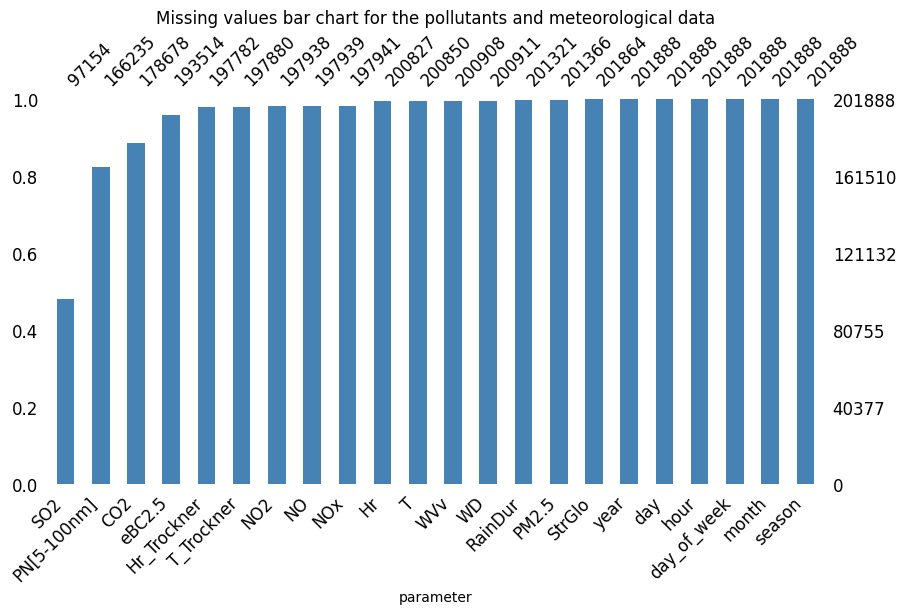

In [21]:
display(df_meteo.isnull().mean().sort_values(ascending=False).round(4) * 100)

missingno.bar(df_meteo, 
              sort='ascending', 
              label_rotation=45,
              color=main_color,
              figsize=(10,5),
              fontsize=12)
plt.title('Missing values bar chart for the pollutants and meteorological data')

## Distributions of the parameters

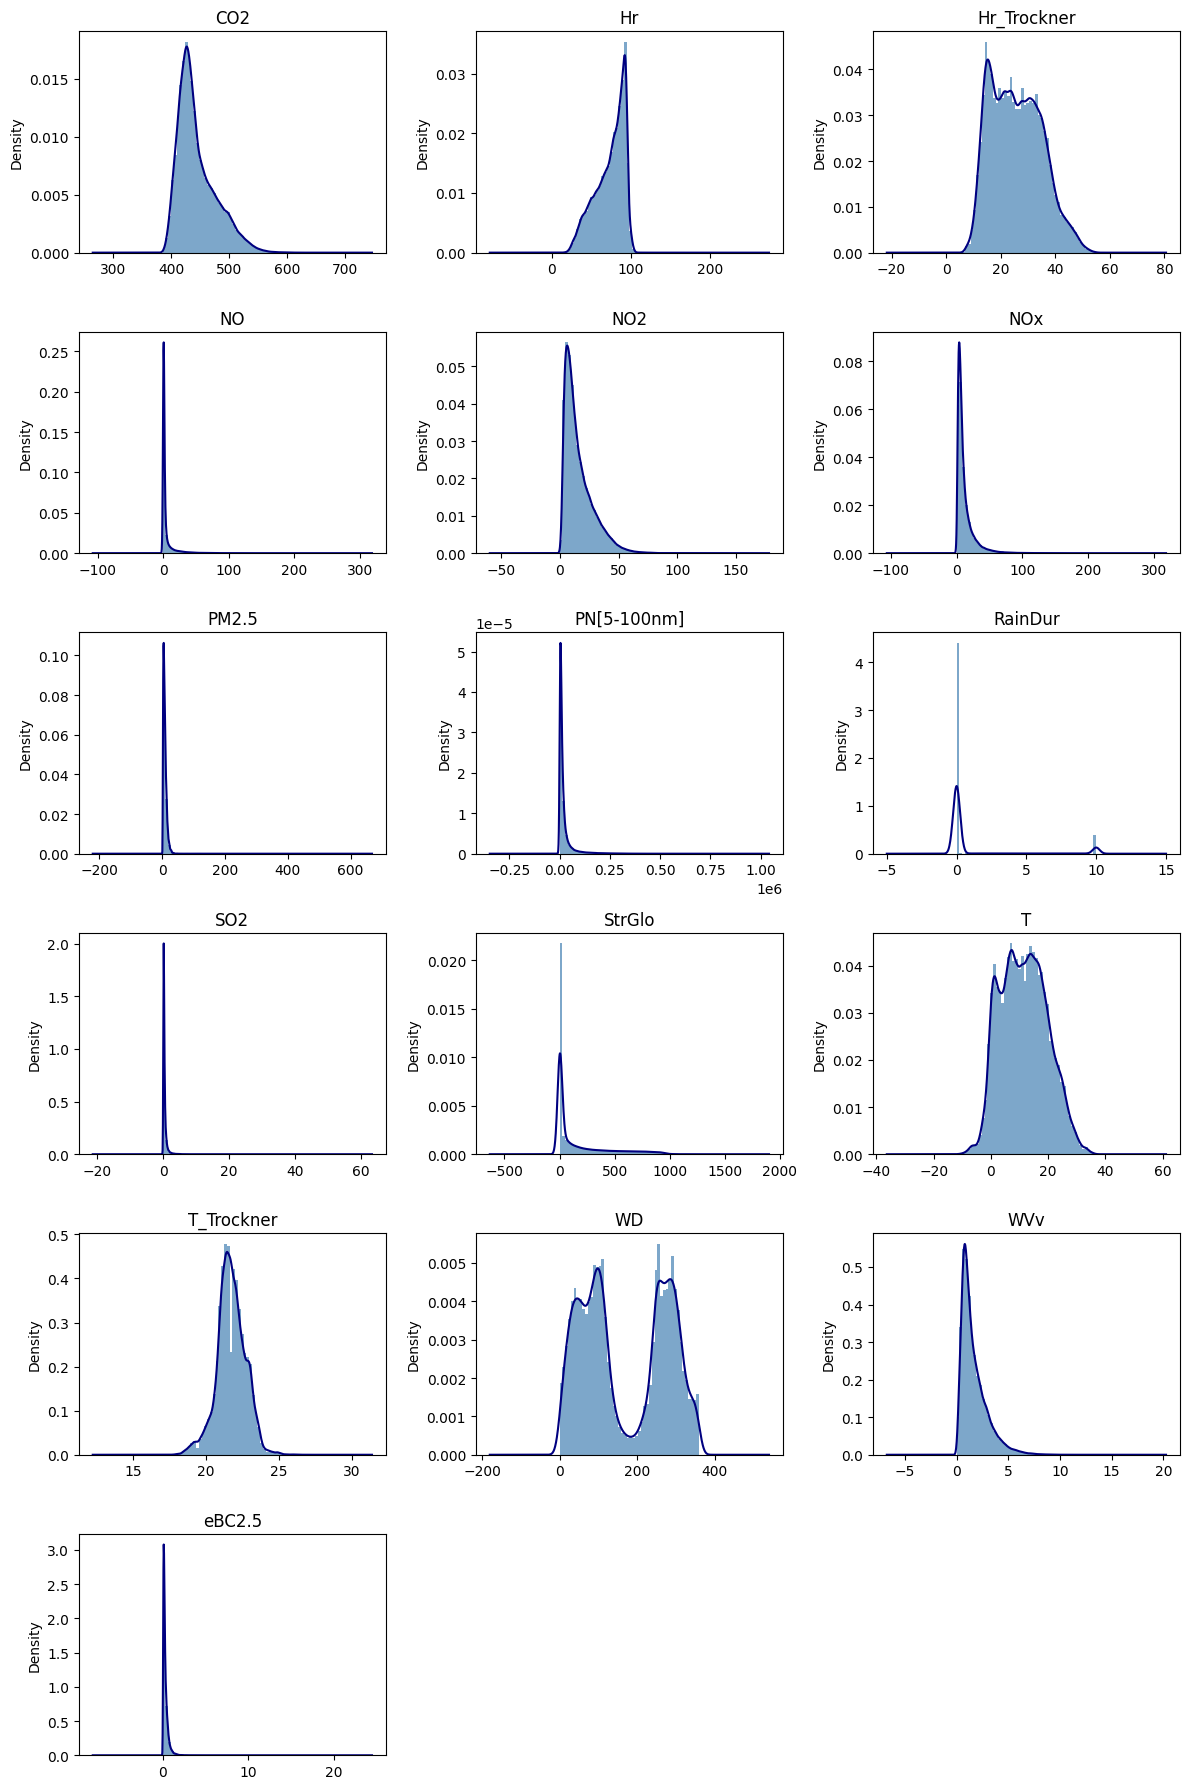

In [25]:
# Visualize the distributions of the parameters, using histograms
# Order them in a grid, with 4 in each row
n_cols = 3
n_rows = (len(parameter_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(parameter_columns):
    df_meteo[col].plot(kind='hist', bins=50, alpha=0.7, ax=axes[i], color=main_color, density=True)
    df_meteo[col].plot.kde(ax=axes[i], color=dark_color)  # optional KDE overlay
    axes[i].set_title(col)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Missing data

Since $SO_2$, PN[5-100nm] and $CO_2$ parameters are missing for significant amounts of entries (52%, 17%, and 11% respectively), we will exclude this parameters from the analysis for now.

If these prove relevant (especially PN[5-100nm] might be important), we will return later to the question of how to best interpolate/impute the missing data for these variables.

Note that the distributions of $SO_2$ and PN[5-100nm] are strongly concentrated around its mode, so we could impute the missing data with those values. This is not true for the $CO_2$, so we might need a different strategy in that case.

The rest of the parameters are not missing a significant amount of data, so we will try to estimate these.

As we are dealing with a time series data, we want to interpolate the missing values.

First we visualize how the missing values are distributed through time

Text(0.5, 1.0, 'Missing Values Matrix')

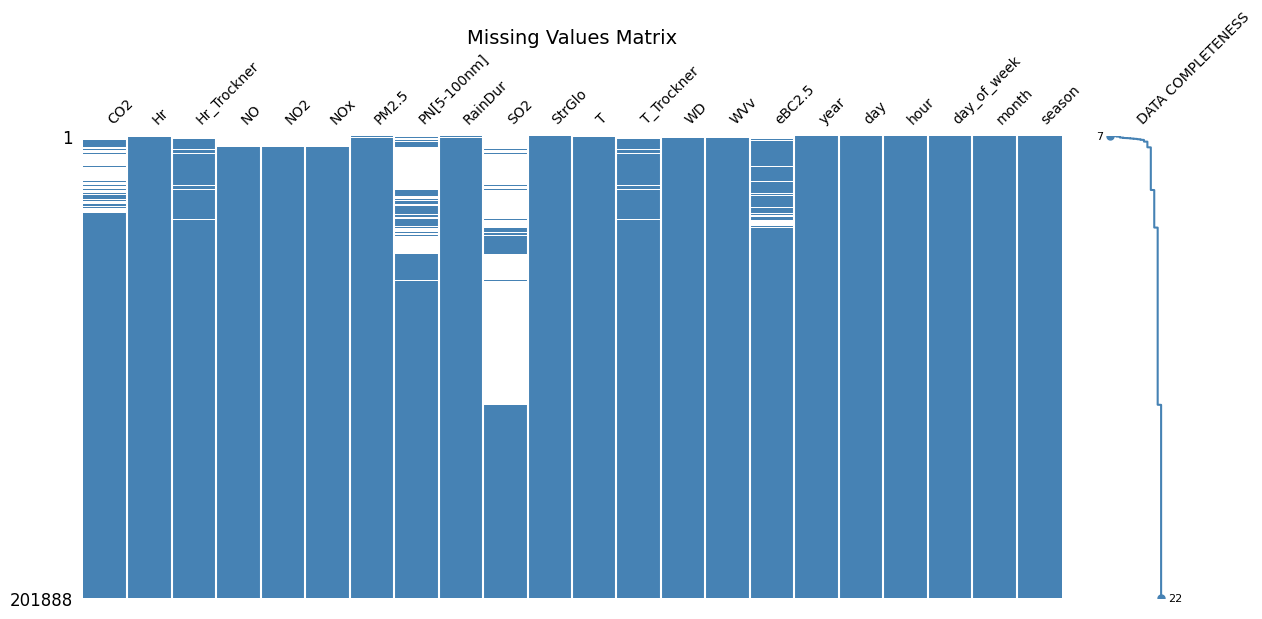

In [31]:
# Showing the distribution of missing values

from matplotlib import colors

missingno.matrix(df_meteo,
                 figsize=(14,6), 
                 fontsize=10, 
                 sort='ascending',
                 sparkline=True,
                 labels=True, 
                 label_rotation=45,
                 color=colors.to_rgb(main_color))
plt.title('Missing Values Matrix', fontsize=14)

We first draw the time series of parameters before missing value imputation/interpolation

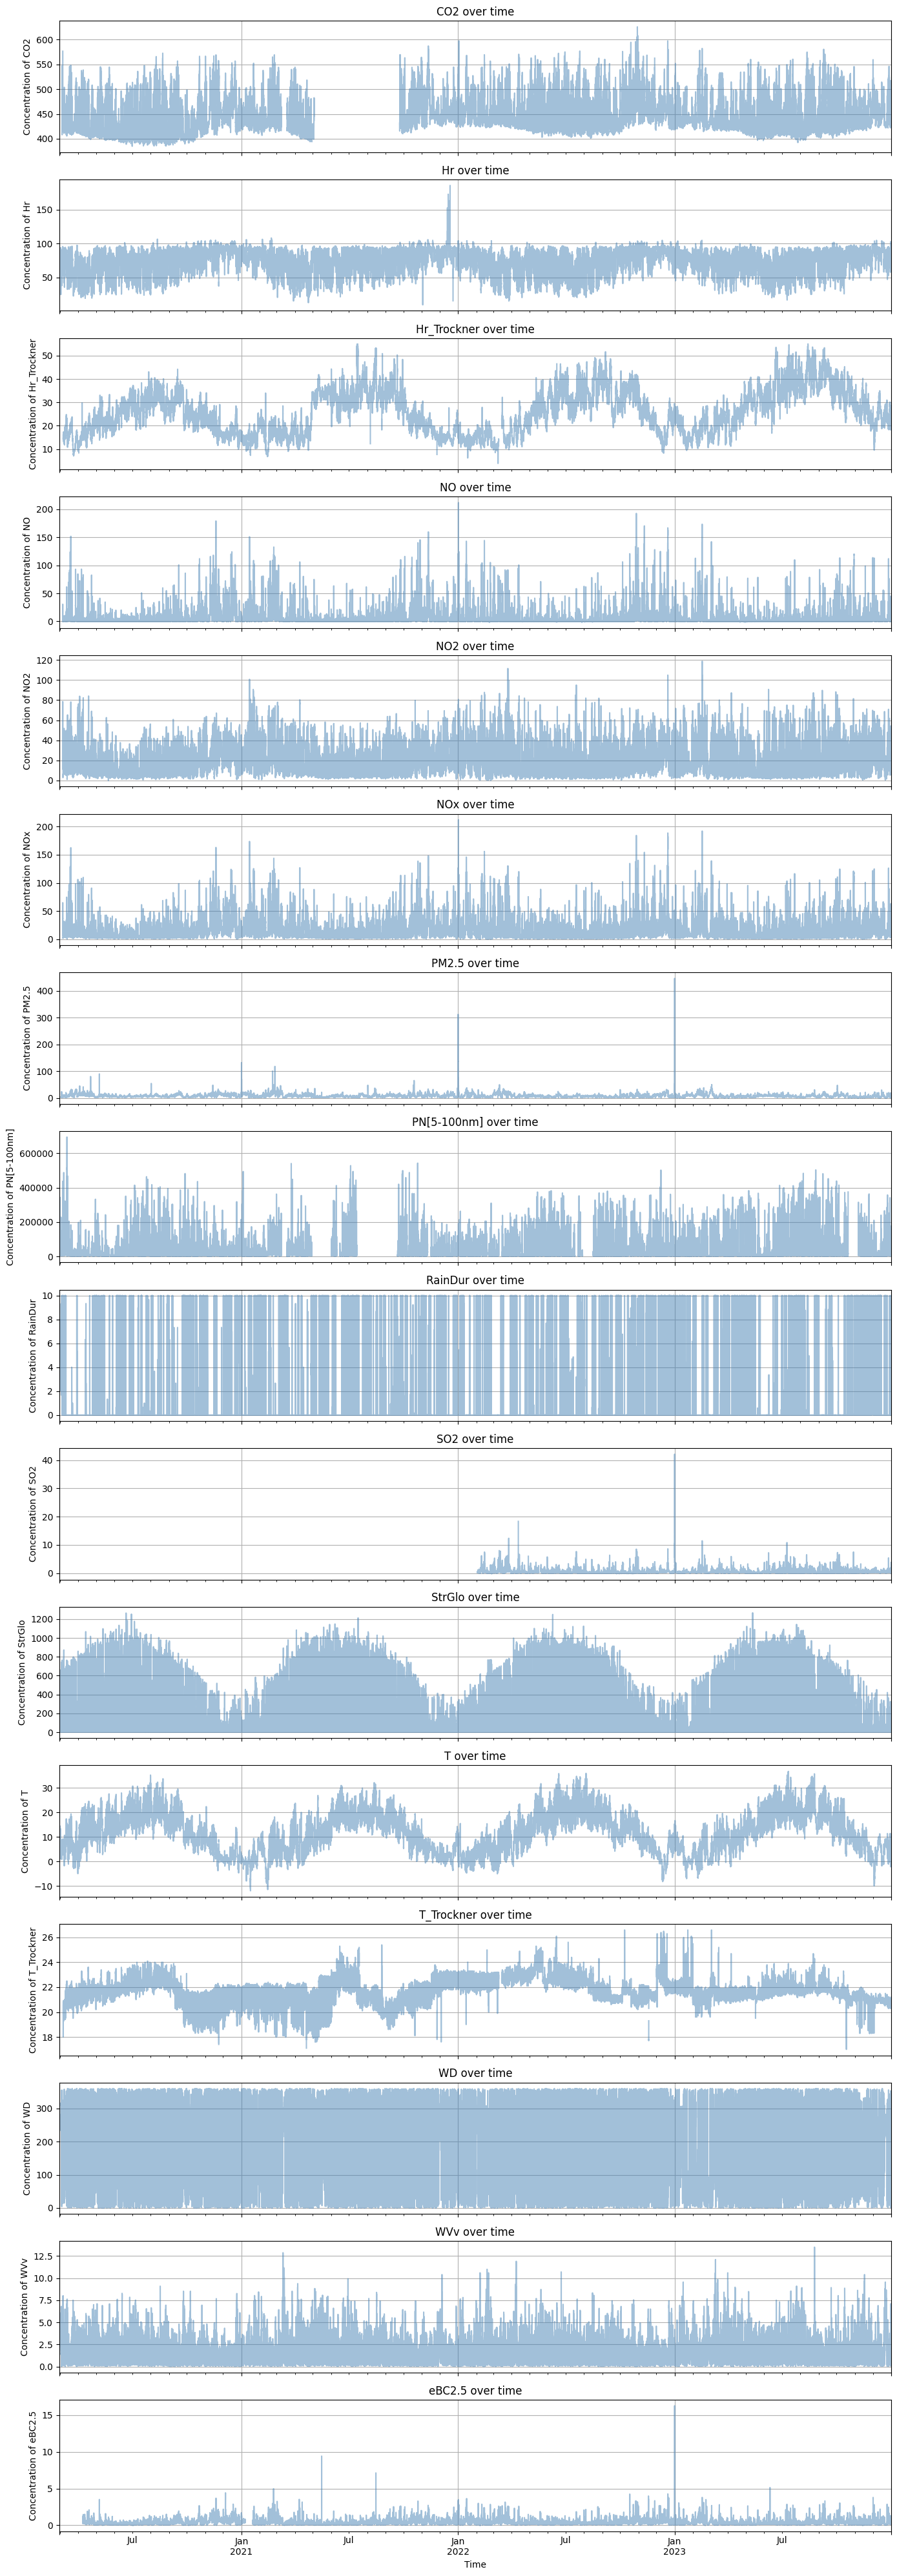

In [33]:
# pollutants = ['PM2.5', 'PN[5-100nm]', 'NOx']
# all_pollutants = ['CO2', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]', 'SO2','eBC2.5']
# meteo_pivoted_df[pollutants].plot(figsize=(15,6), alpha=0.8)
# plt.legend(title='Pollutant')

# plt.show()
# for col in pollutants:
#     meteo_pivoted_df[col].plot(figsize=(15,6), alpha=0.8)
#     plt.legend(title='Pollutant')
#     plt.show()

fig, axes = plt.subplots(nrows=len(parameter_columns), ncols=1, figsize=(14,40), sharex=True)

for i, col in enumerate(parameter_columns):
    # Original, non-smoothed data
    df_meteo[col].plot(ax=axes[i], alpha=0.5, label='Original data', color=main_color)
    # Smoothed line (1-hour rolling average)
    # df_meteo[col].rolling(window=18, center=True).median().plot(ax=axes[i], alpha=0.9, label='1-day rolling avg', color=accent_color)

    axes[i].set_title(f'{col} over time')
    axes[i].set_ylabel(f'Concentration of {col}')
    axes[i].grid(True)

plt.xlabel('Time')
plt.tight_layout()
plt.show()

In [15]:
def max_nan_streak_per_column(df):
    max_streaks = {}
    for col in df.columns:
        is_na = df[col].isna()
        # Use cumsum of negated mask to group contiguous values
        streaks = (is_na != is_na.shift()).cumsum()
        max_streak = is_na.groupby(streaks).sum().max()
        max_streaks[col] = int(max_streak) if not np.isnan(max_streak) else 0
    return pd.Series(max_streaks, name='max_nan_streak')

nan_streaks = max_nan_streak_per_column(df_meteo[parameter_columns])
print(nan_streaks.sort_values(ascending=False))

SO2            101447
CO2             20757
PN[5-100nm]      9871
eBC2.5           5694
Hr_Trockner       937
T_Trockner        937
NO                816
NO2               816
NOx               816
RainDur           391
PM2.5             387
WD                375
WVv               375
Hr                150
T                 150
StrGlo              4
Name: max_nan_streak, dtype: int64


**Idea** : use the time series nature of the data and interpolate missing values from the surrounding data

**Potential problems** : if the gaps are too big

We see that `'StrGlo'` is very safe to interpolate from surrounding data.

Most columns are in the middle range: longest streaks have lengths of few days (144*10min = 1 day). These are:

`['Hr_Trockner', 'T_Trockner', 'NO', 'NO2', 'NOx', 'RainDur', 'PM2.5', 'WD', 'WVv', 'Hr', 'T']`

`SO2` and `CO2` will be dropped, while we will decide on `PN[5-100nm]` and `eBC2.5` later

In [16]:
df_meteo.isnull().mean().sort_values(ascending=False).round(4) * 100

parameter
SO2            51.88
PN[5-100nm]    17.66
CO2            11.50
eBC2.5          4.15
Hr_Trockner     2.03
T_Trockner      1.99
NO2             1.96
NO              1.96
NOx             1.96
Hr              0.53
T               0.51
WVv             0.49
WD              0.48
RainDur         0.28
PM2.5           0.26
StrGlo          0.01
year            0.00
day             0.00
hour            0.00
day_of_week     0.00
month           0.00
season          0.00
dtype: float64

## Test missingness patterns

First we check how are missing values correlated across different variables

Text(0.5, 1.0, 'Missing Values Heatmap')

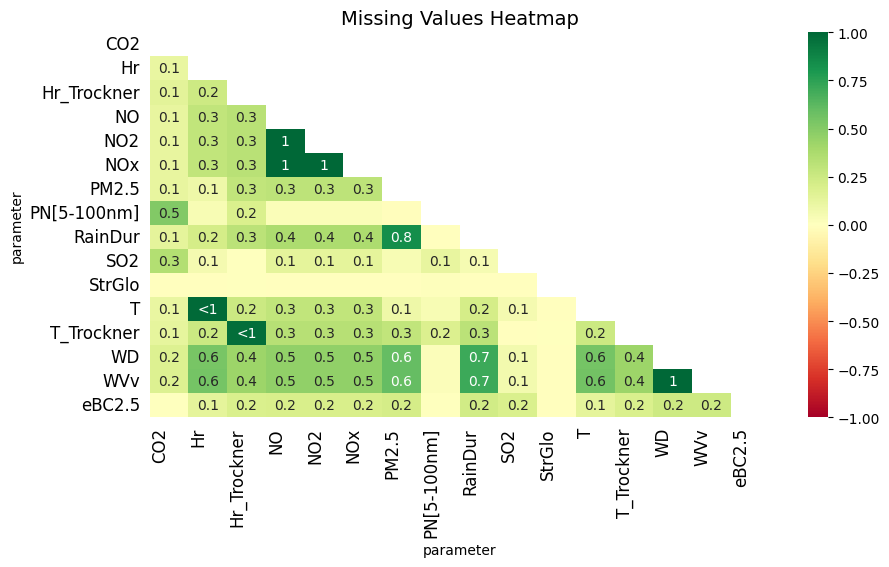

In [17]:
missingno.heatmap(df_meteo[parameter_columns], 
                  figsize=(10,5), 
                  fontsize=12,
                  cmap='RdYlGn',
                  labels=True,
                  label_rotation=90,)

plt.title('Missing Values Heatmap', fontsize=14)

Observations:
- NO, NO2 and NOx are highly correlated (to be expected, especially as NOx = NO2 + NO)
- T (temperature) and Hr (relative humidity) highly correlated missingness
- T_Trockner (temperature) and Hr_Trockner (relative humidity) highly correlated missingness
- WD and WVv (wind measurments) highly correlated
- no reverse correlations
Medium correlation:
- PN[5-100nm] and CO2 (note: both of these have many missing values)
- PM2.5, wind measurments WD and WVv, and RainDur (all of these have some missing data at the beginning of the timespan measured)
- WD, WVv with Hr, Hr_Trockner, NO, NO2, NOx, T, T_Trockner

Next, we check how missingness patterns behave through time - e.g., are there any long gaps

In [20]:
# extract year, hour, day etc as separate variables

df_meteo['year'] = df_meteo.index.year
df_meteo['day'] = df_meteo.index.date
df_meteo['hour'] = df_meteo.index.hour
df_meteo['day_of_week'] = df_meteo.index.weekday
df_meteo['month'] = df_meteo.index.month

# Define seasons - use meteorological seasons (by months) for simplicity

season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}

df_meteo['season'] = df_meteo['month'].map(season_map)

In [22]:
# save the dataset with defined seasons etc for easier access later
df_meteo.to_parquet(meteo_original_path)

Missingness of CO2:


<Figure size 1500x400 with 0 Axes>

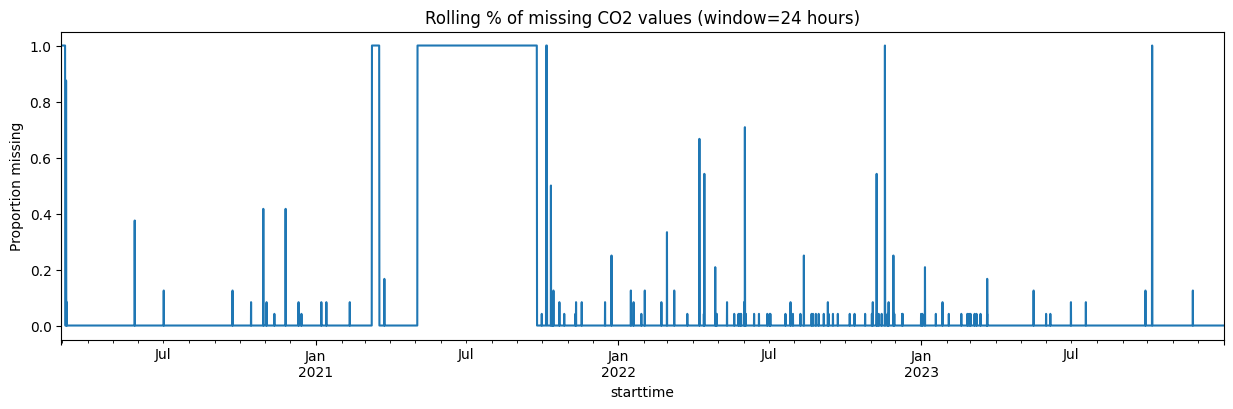

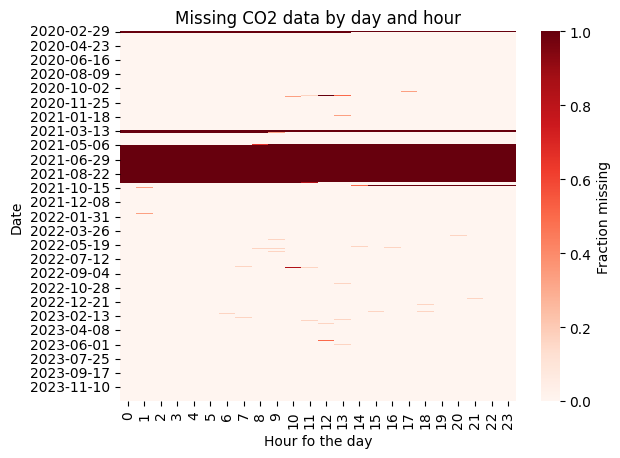

Missingness of Hr:


<Figure size 1500x400 with 0 Axes>

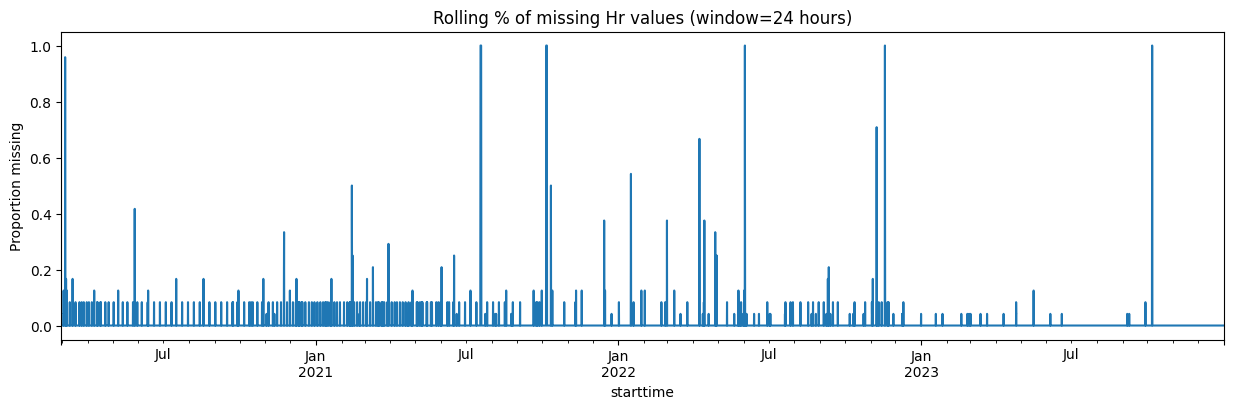

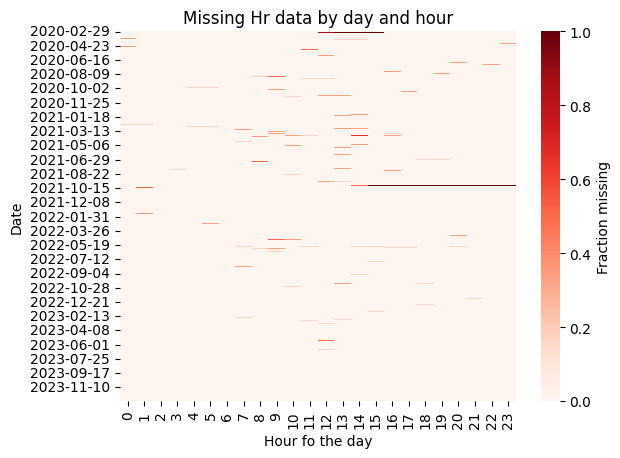

Missingness of Hr_Trockner:


<Figure size 1500x400 with 0 Axes>

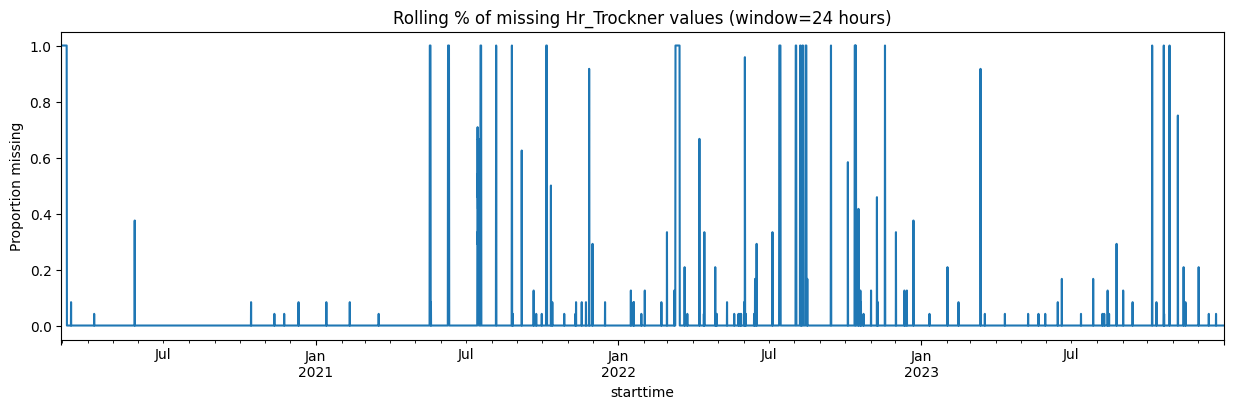

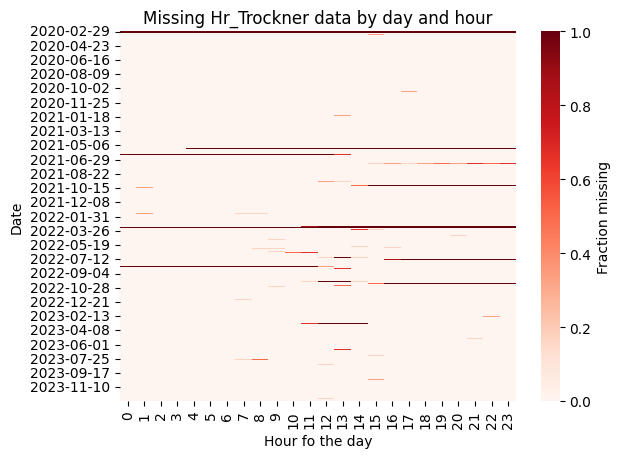

Missingness of NO:


<Figure size 1500x400 with 0 Axes>

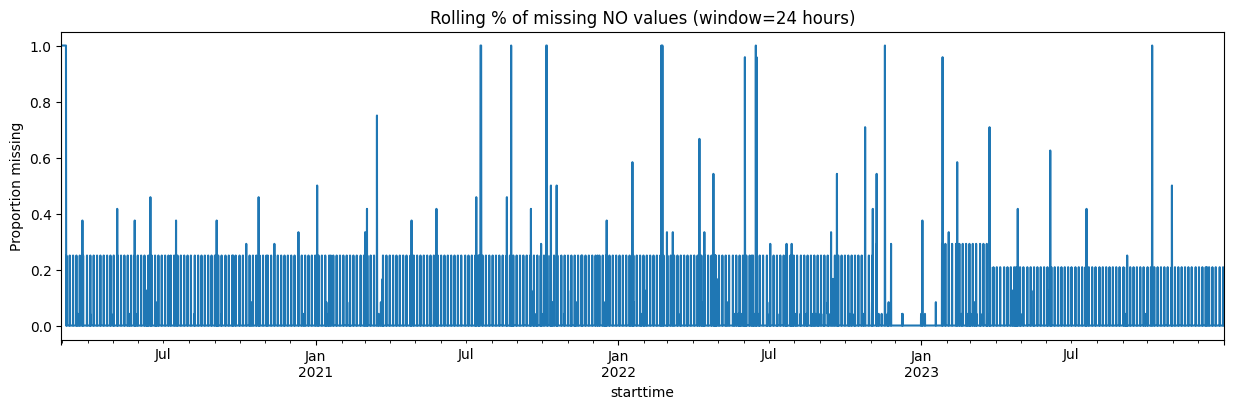

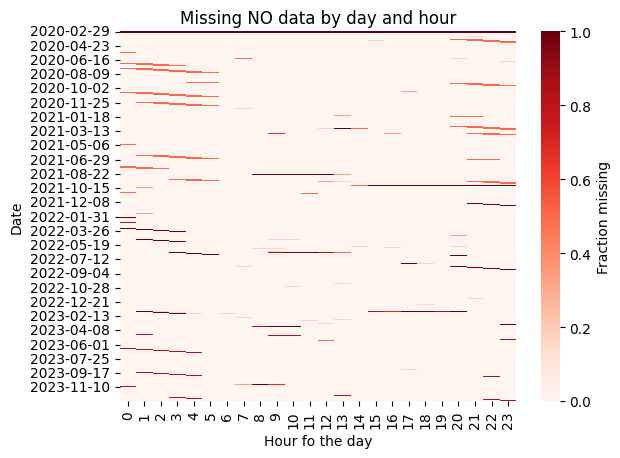

Missingness of NO2:


<Figure size 1500x400 with 0 Axes>

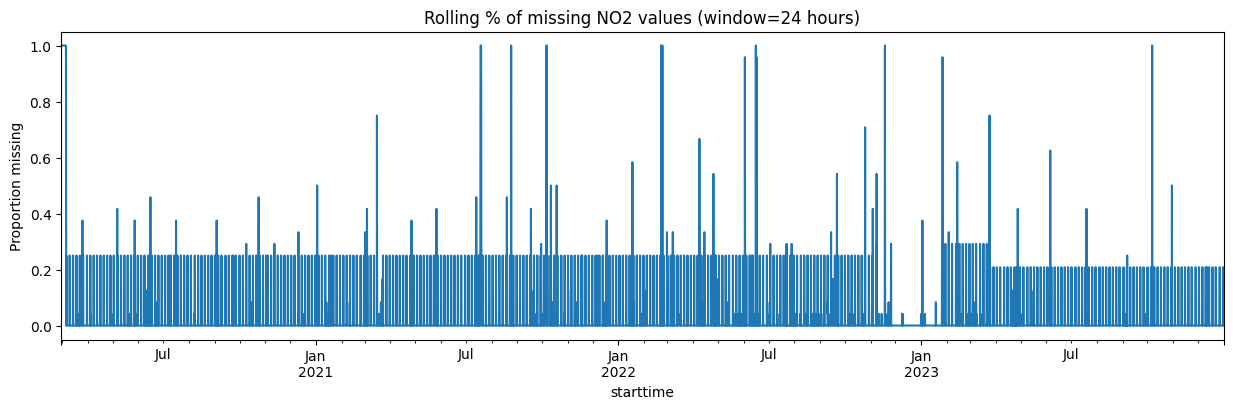

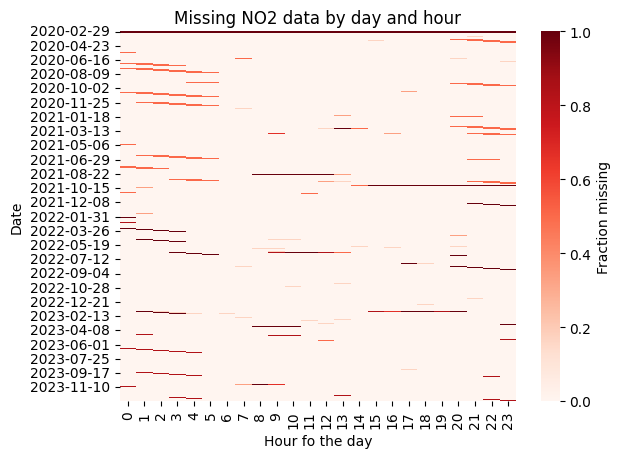

Missingness of NOx:


<Figure size 1500x400 with 0 Axes>

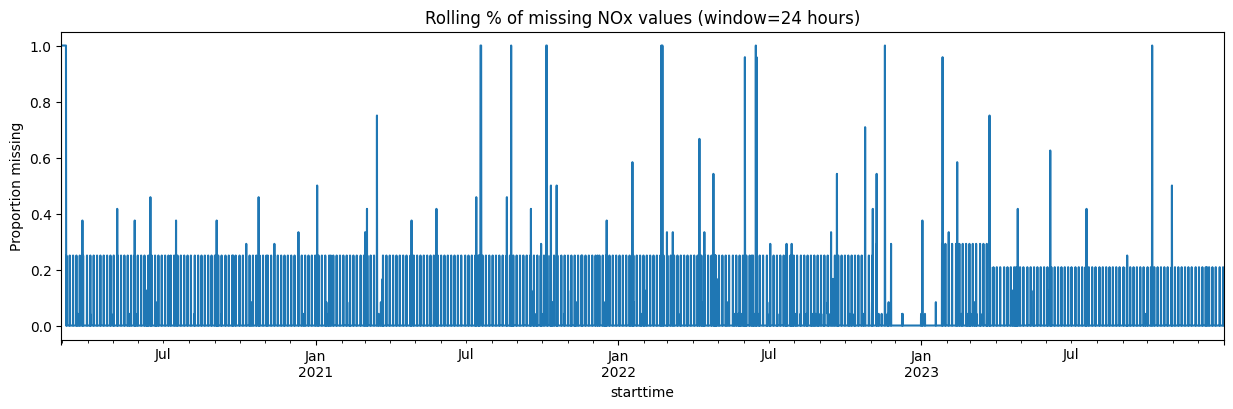

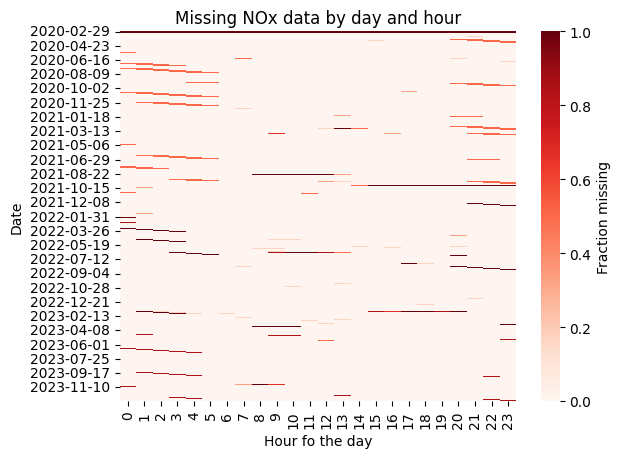

Missingness of PM2.5:


<Figure size 1500x400 with 0 Axes>

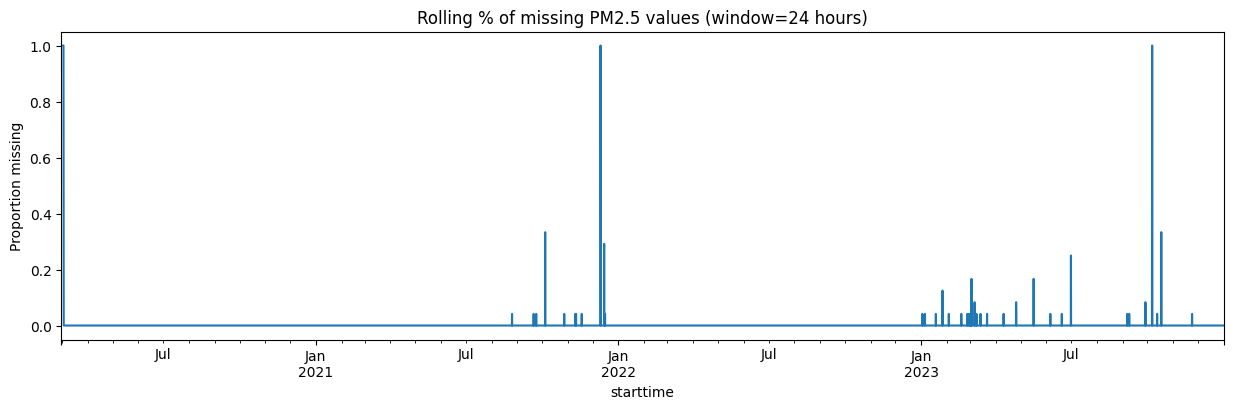

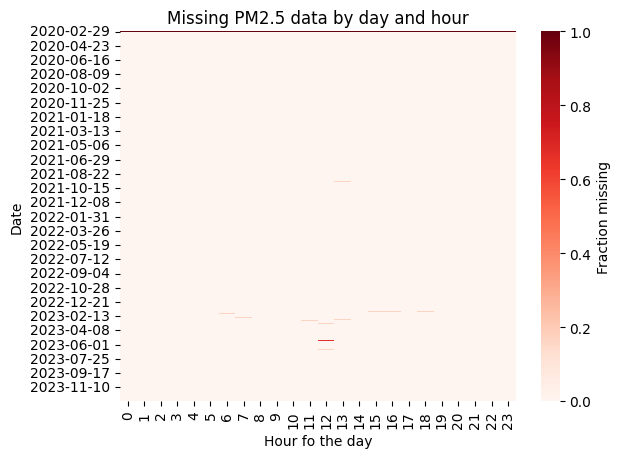

Missingness of PN[5-100nm]:


<Figure size 1500x400 with 0 Axes>

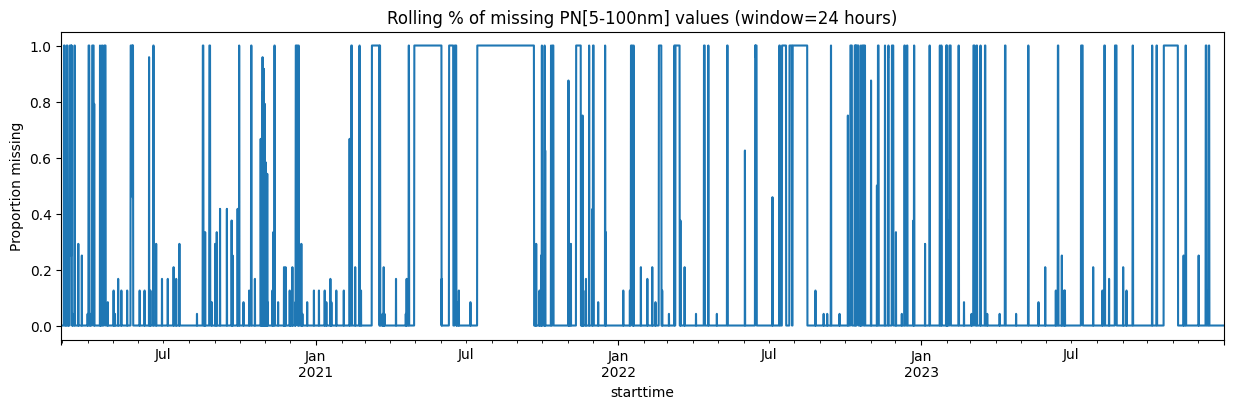

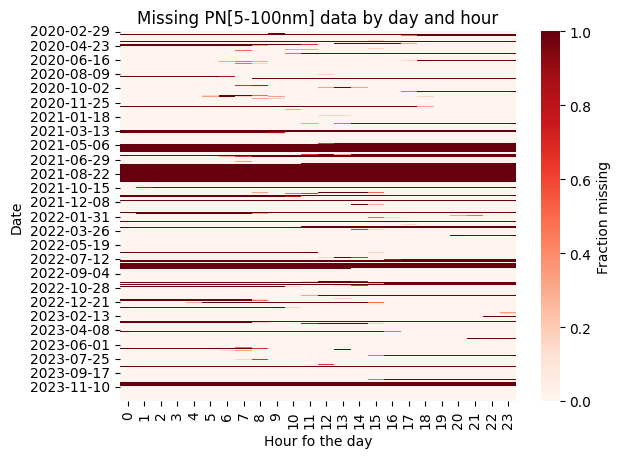

Missingness of RainDur:


<Figure size 1500x400 with 0 Axes>

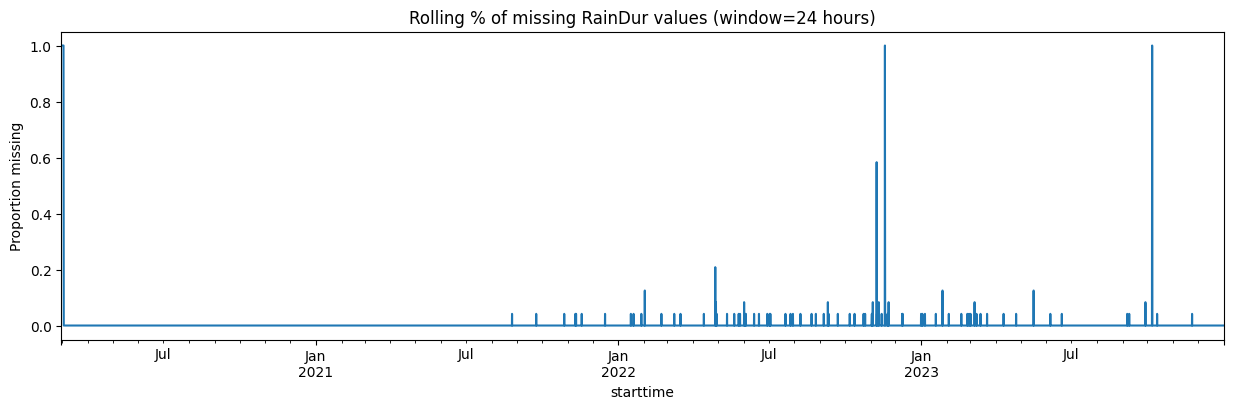

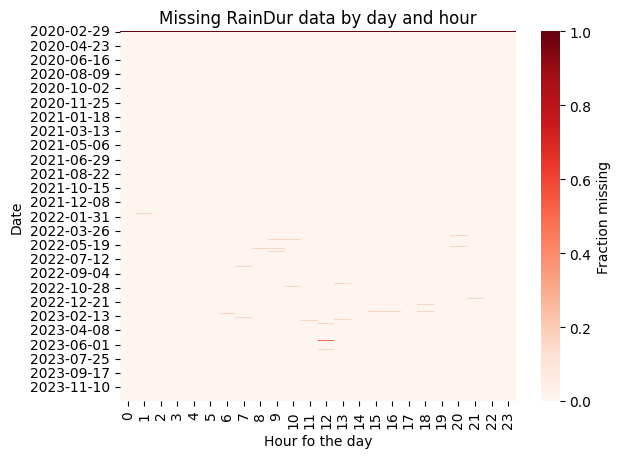

Missingness of SO2:


<Figure size 1500x400 with 0 Axes>

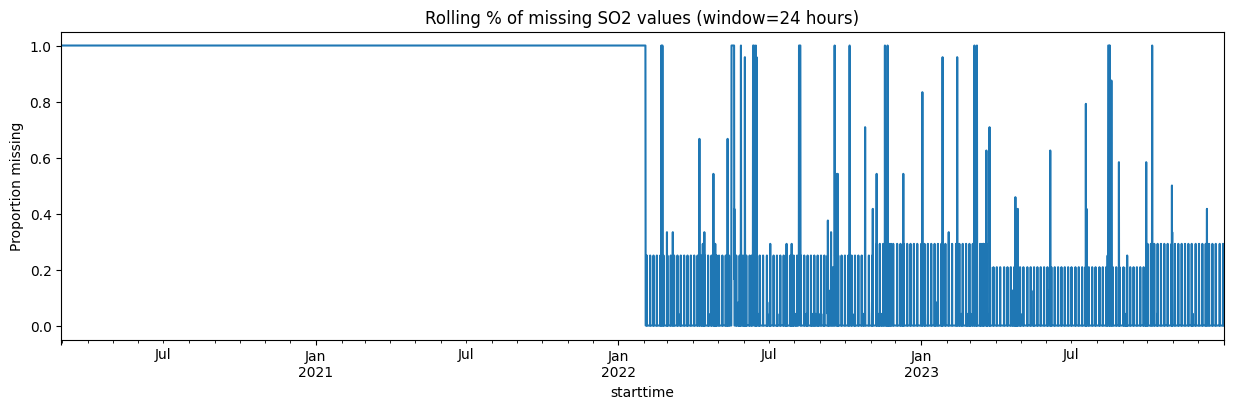

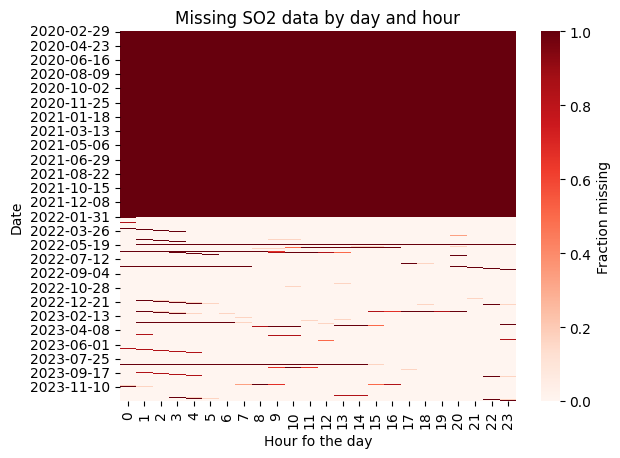

Missingness of StrGlo:


<Figure size 1500x400 with 0 Axes>

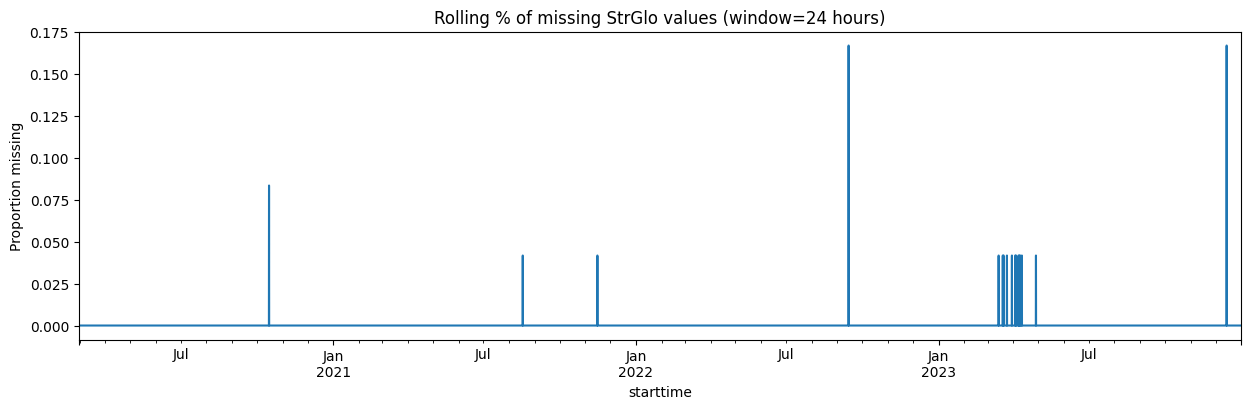

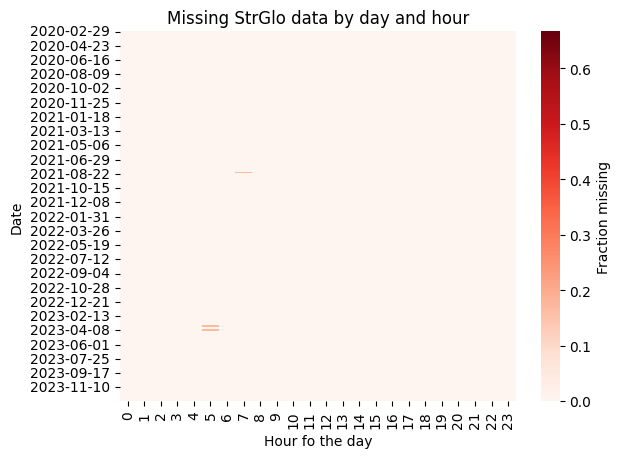

Missingness of T:


<Figure size 1500x400 with 0 Axes>

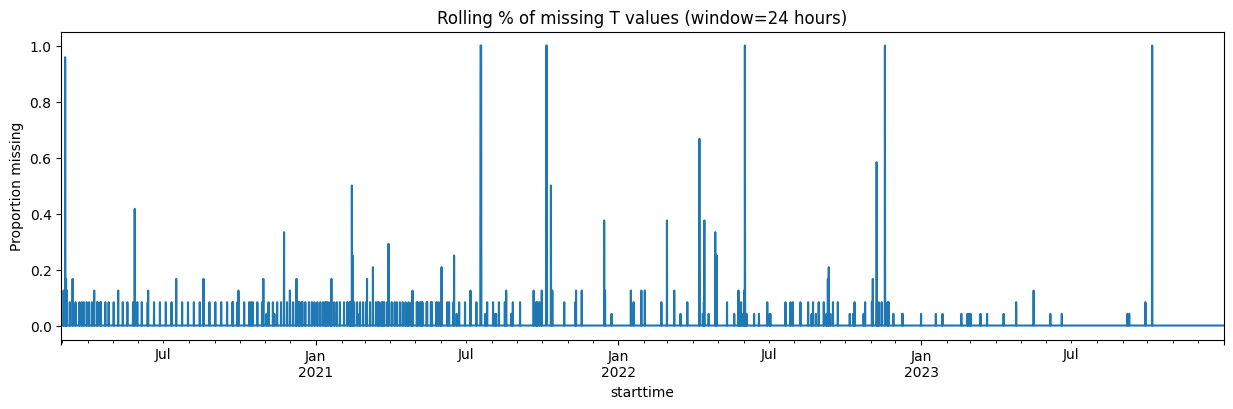

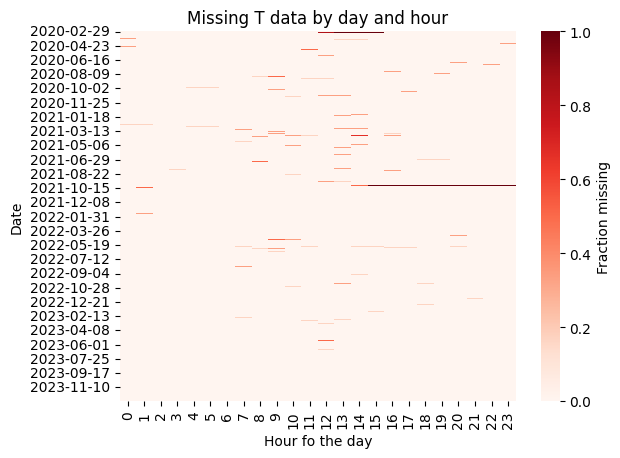

Missingness of T_Trockner:


<Figure size 1500x400 with 0 Axes>

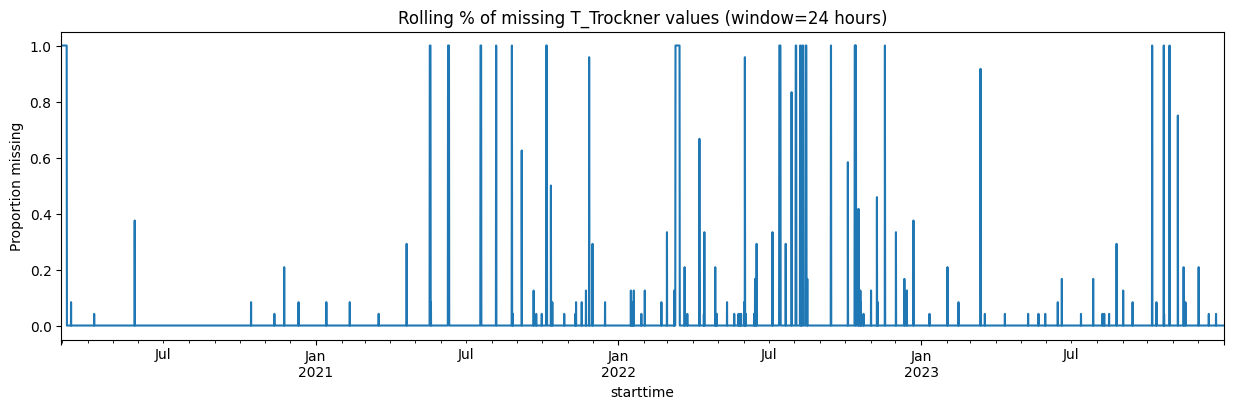

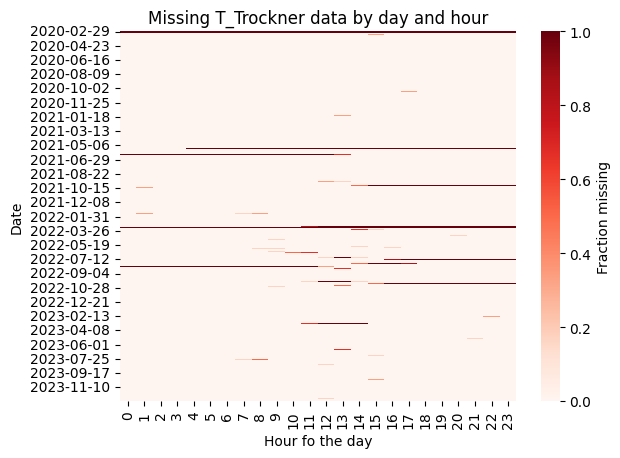

Missingness of WD:


<Figure size 1500x400 with 0 Axes>

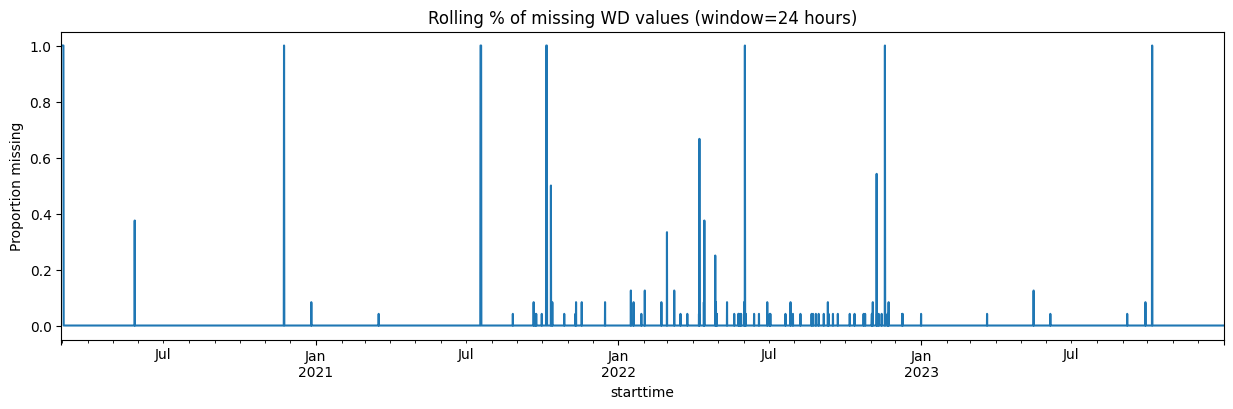

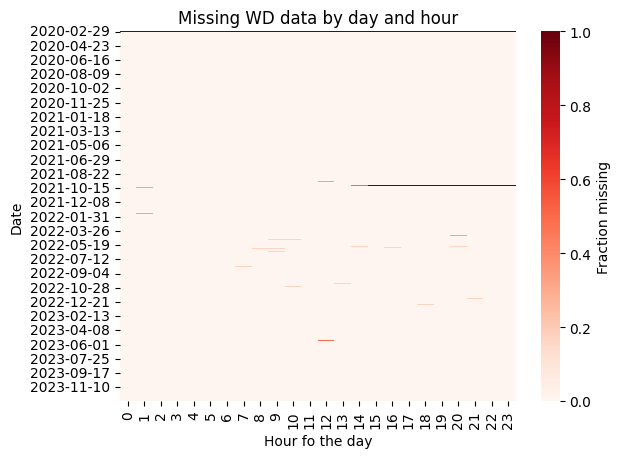

Missingness of WVv:


<Figure size 1500x400 with 0 Axes>

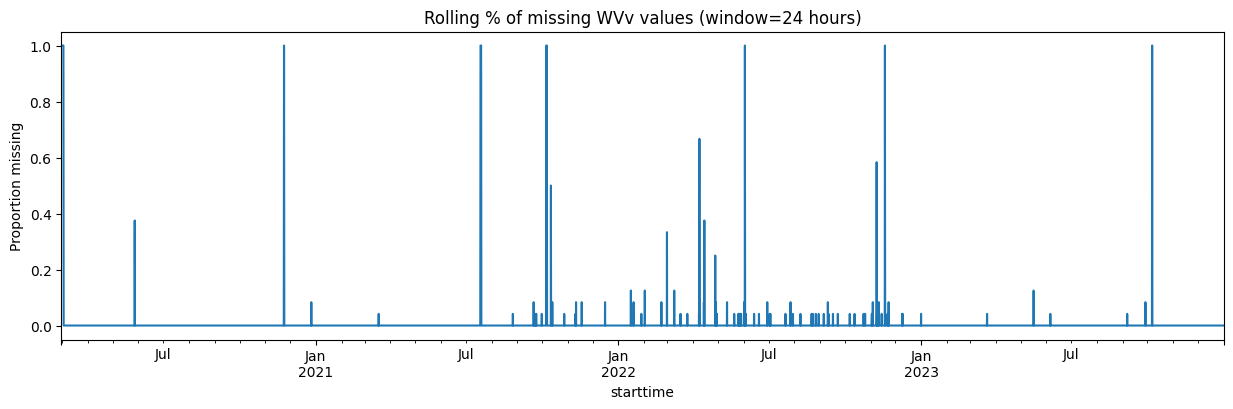

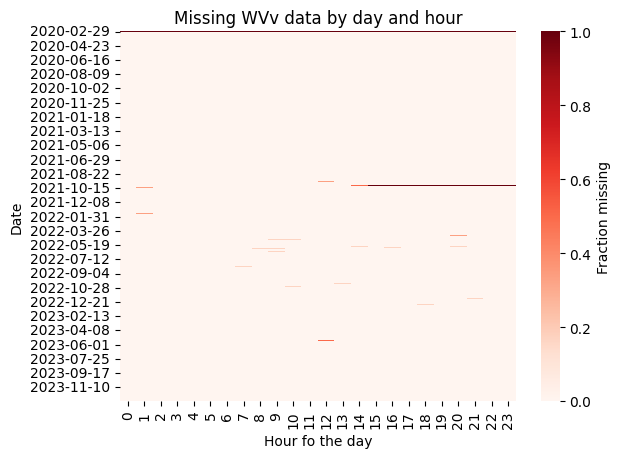

Missingness of eBC2.5:


<Figure size 1500x400 with 0 Axes>

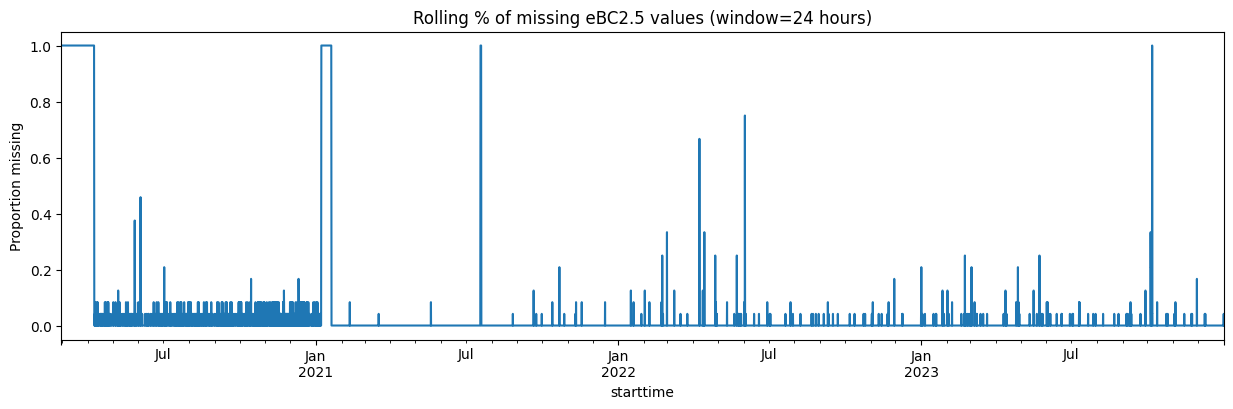

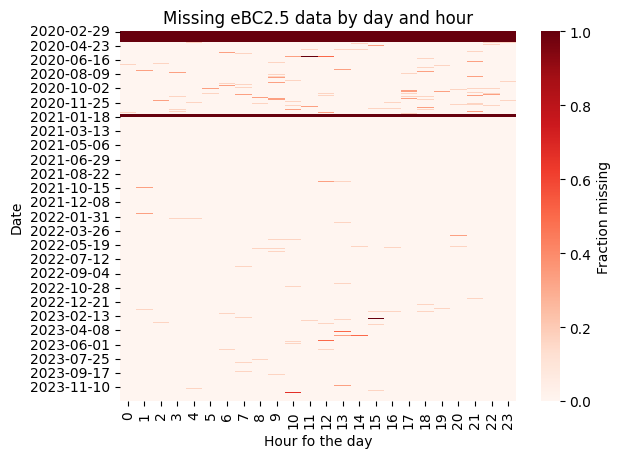

In [18]:
for col in parameter_columns:
    # time series data of missing values
    print(f'Missingness of {col}:')
    missing = df_meteo[col].isna()
    # plot time series of missing values
    plt.figure(figsize=(15,4))
    plt.figure(figsize=(15, 4))
    missing.astype(int).rolling(window=24).mean().plot()
    plt.title(f"Rolling % of missing {col} values (window=24 hours)")  
    plt.ylabel("Proportion missing")
    plt.show()

    # heatmap of missingness by hour & day
    pivot = df_meteo.pivot_table(values=col, index='day', columns='hour', aggfunc=lambda x: x.isna().mean())

    plt.Figure(figsize=(14,6))
    sns.heatmap(pivot, cmap='Reds', cbar_kws={'label': 'Fraction missing'})
    plt.title(f'Missing {col} data by day and hour')
    plt.xlabel('Hour fo the day')
    plt.ylabel('Date')
    plt.show()

Separate columns into pollutants (targets) and weather data (features).

For pollutants which don't have too long stretches of time without data:
- if data is completely missing for one day, drop it
- only partial missingness for a day -> interpolate

For weather data:
- be more tolerant, avoid dropping just because one weather feature is missing
- impute using interpolation, forwad/backward fill, or climatological averages

In [19]:
parameter_columns

['CO2',
 'Hr',
 'Hr_Trockner',
 'NO',
 'NO2',
 'NOx',
 'PM2.5',
 'PN[5-100nm]',
 'RainDur',
 'SO2',
 'StrGlo',
 'T',
 'T_Trockner',
 'WD',
 'WVv',
 'eBC2.5']

In [20]:
pollutants_columns = ['CO2', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]', 'SO2',  'eBC2.5']
weather_columns = ['Hr', 'Hr_Trockner', 'RainDur', 'StrGlo', 'T', 'T_Trockner', 'WD', 'WVv']
print(pollutants_columns)
print(weather_columns)

['CO2', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]', 'SO2', 'eBC2.5']
['Hr', 'Hr_Trockner', 'RainDur', 'StrGlo', 'T', 'T_Trockner', 'WD', 'WVv']


In [21]:

def remove_fully_missing_days(df, columns):
    '''Removes dates from the dataframe where data is missing 
    for the whole date for at least one column in columns'''

    # initialize days to remove
    days_to_remove = set()

    for col in columns:
        daily_missing = df[col].isna().resample('D').mean()
        fully_missing_days = daily_missing[daily_missing == 1.0].index
        days_to_remove.update(fully_missing_days)
        print(f"{col}: {len(fully_missing_days)} fully missing days")
    
    # filter those timestamps where the days are not in days_to_remove
    df_cleaned = df[~df.index.normalize().isin(days_to_remove)].copy()
    print(f"Total days removed from the dataframe: {len(days_to_remove)}")
    return df_cleaned



In [22]:
print(df_meteo['day'].nunique())

1402


In [23]:
pollutants_remove_days = ['NO', 'NO2', 'NOx', 'PM2.5']
pollutants_interpolate = ['NO', 'NO2', 'NOx', 'PM2.5','eBC2.5', 'PN[5-100nm]']
pollutants_ignore = ['CO2', 'SO2']

In [24]:
# Remove the days where the data on at least one pollutant is fully missing
# Disregard SO2, CO2, PM2.5 as

df_cleaned = remove_fully_missing_days(df_meteo, pollutants_remove_days)

NO: 5 fully missing days
NO2: 5 fully missing days
NOx: 5 fully missing days
PM2.5: 2 fully missing days
Total days removed from the dataframe: 5


Other pollutants have too long stretches to fully remove.

CO2 and SO2 we will ignore for now, as they have too much data missing

For others we use interpolation.

Set different limits, depending on the nature of the pollutants (more stable or more volatile)

In [25]:
interpolation_limits = {
    'PM2.5': 288,           # up to 2 days
    'NOx': 144,             # up to 1 day
    'NO': 144,             # up to 1 day
    'NO2': 144,             # up to 1 day
    'eBC2.5': 72,           # up to 12 hours
    'PN[5-100nm]': 12       # up to 2 hours
}

for col, limit in interpolation_limits.items():
    was_na = df_cleaned[col].isna()
    df_cleaned.loc[:,col] = df_cleaned[col].interpolate(method='time', limit=limit, limit_direction='both')
    still_na = df_cleaned[col].isna()
    df_cleaned.loc[:,f'{col}_gap_too_long'] = (was_na & still_na).astype(int)
    df_cleaned.loc[:, f'{col}_was_interpolated'] = (was_na & ~still_na).astype(int)


missing_summary = df_cleaned[pollutants_interpolate].isna().sum()
print("\nRemaining missing values after interpolation:\n", missing_summary)


Remaining missing values after interpolation:
 parameter
NO                 0
NO2                0
NOx                0
PM2.5              0
eBC2.5          6515
PN[5-100nm]    32419
dtype: int64


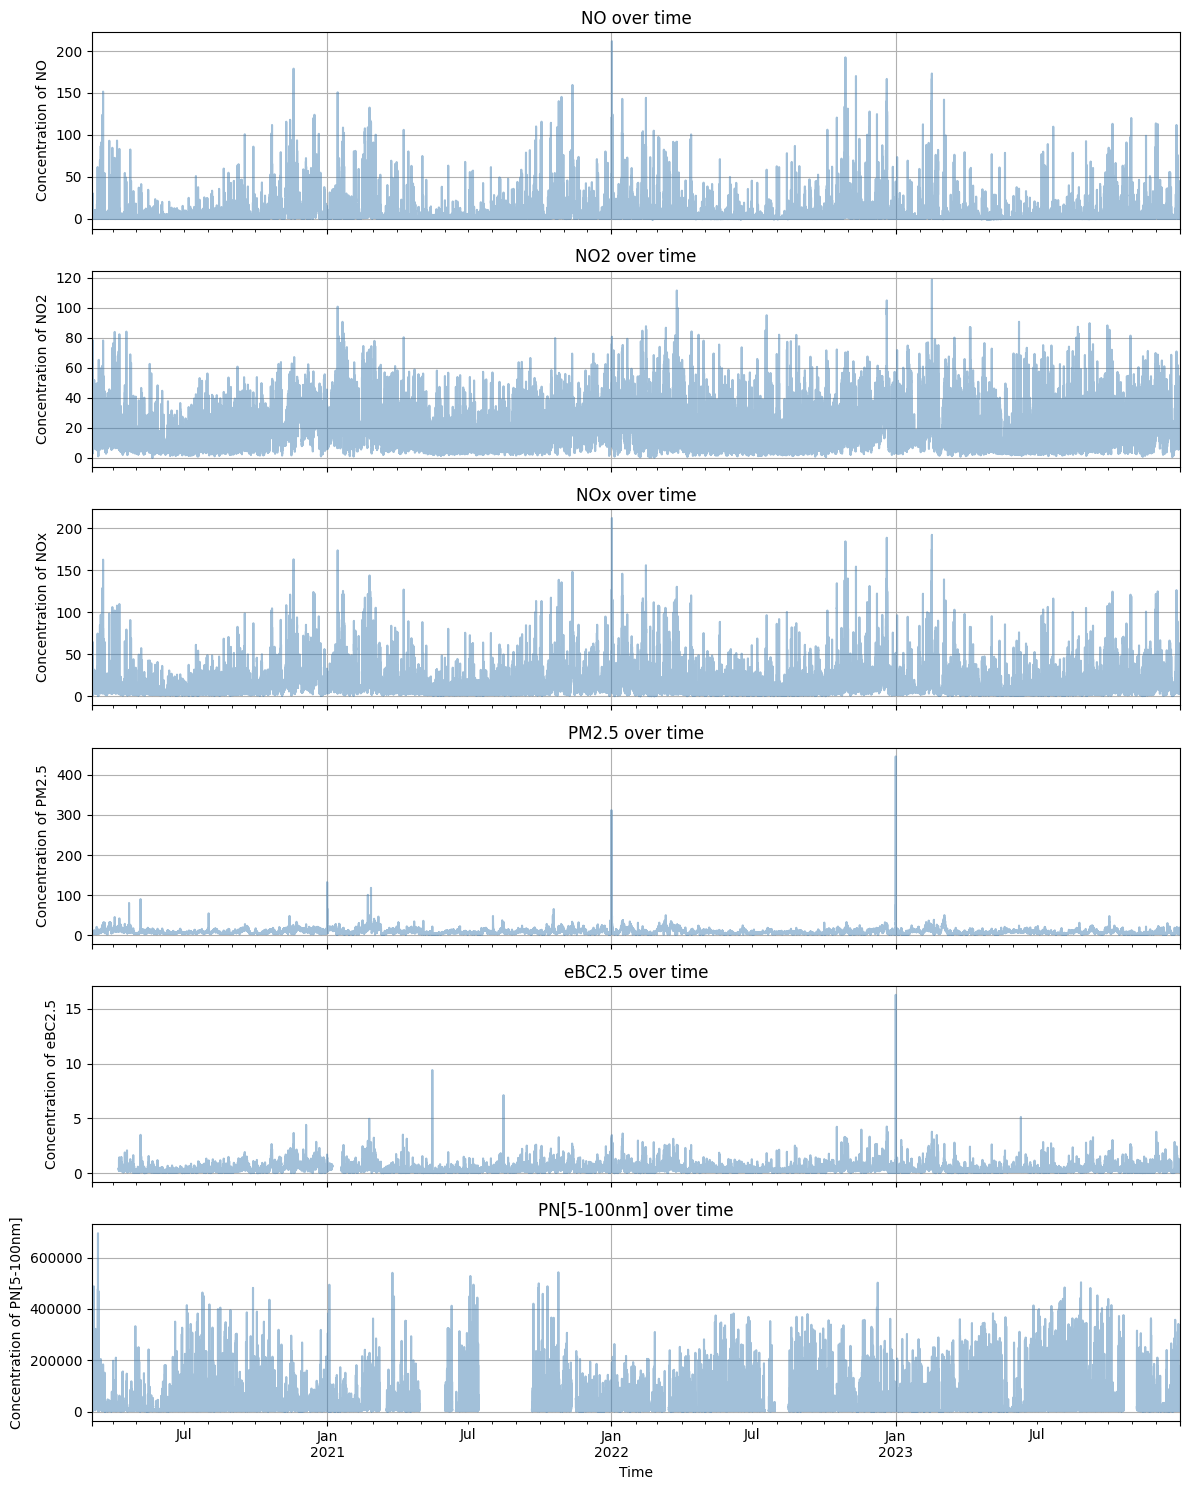

In [26]:
fig, axes = plt.subplots(nrows=len(pollutants_interpolate), ncols=1, figsize=(12,15), sharex=True)

for i, col in enumerate(pollutants_interpolate):
    # Original, non-smoothed data
    df_cleaned[col].plot(ax=axes[i], alpha=0.5, label='Original data', color=main_color)
    # Smoothed line (1-hour rolling average)
    # df_meteo[col].rolling(window=18, center=True).median().plot(ax=axes[i], alpha=0.9, label='1-day rolling avg', color=accent_color)

    axes[i].set_title(f'{col} over time')
    axes[i].set_ylabel(f'Concentration of {col}')
    axes[i].grid(True)

plt.xlabel('Time')
plt.tight_layout()
plt.show()

In [27]:
# interpolate weather data, with limit 6*24=144

for col in weather_columns:
    was_na = df_cleaned[col].isna()
    df_cleaned.loc[:,col] = df_cleaned[col].interpolate(method='time', limit=144, limit_direction='both')

    still_na = df_cleaned[col].isna()
    df_cleaned.loc[:,f'{col}_gap_too_long'] = (was_na & still_na).astype(int)
    df_cleaned.loc[:, f'{col}_was_interpolated'] = (was_na & ~still_na).astype(int)

missing_summary = df_cleaned[weather_columns].isna().sum()
print("\nRemaining missing values after interpolation:\n", missing_summary)
    


Remaining missing values after interpolation:
 parameter
Hr               0
Hr_Trockner    530
RainDur          0
StrGlo           0
T                0
T_Trockner     530
WD               0
WVv              0
dtype: int64


**Summary**

- Weather data is now complete, apart from Hr_Trockner and T_Trockner, which might be possible to impute from Hr and T
- NO, NO2, NOx, PM2.5 are complete and trustworthy
- eBC2.5, PN[5-100nm] still have long sections with missing values
- for all variables we have flags where they were interpolated, and for the sections that are still missing

In [28]:
path_df_cleaned = 'Data/meteo_pivoted_cleaned.parquet'

df_cleaned.to_parquet(path_df_cleaned)

In [29]:
df_cleaned.columns

Index(['CO2', 'Hr', 'Hr_Trockner', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]',
       'RainDur', 'SO2', 'StrGlo', 'T', 'T_Trockner', 'WD', 'WVv', 'eBC2.5',
       'year', 'day', 'hour', 'day_of_week', 'month', 'season',
       'PM2.5_gap_too_long', 'PM2.5_was_interpolated', 'NOx_gap_too_long',
       'NOx_was_interpolated', 'NO_gap_too_long', 'NO_was_interpolated',
       'NO2_gap_too_long', 'NO2_was_interpolated', 'eBC2.5_gap_too_long',
       'eBC2.5_was_interpolated', 'PN[5-100nm]_gap_too_long',
       'PN[5-100nm]_was_interpolated', 'Hr_gap_too_long',
       'Hr_was_interpolated', 'Hr_Trockner_gap_too_long',
       'Hr_Trockner_was_interpolated', 'RainDur_gap_too_long',
       'RainDur_was_interpolated', 'StrGlo_gap_too_long',
       'StrGlo_was_interpolated', 'T_gap_too_long', 'T_was_interpolated',
       'T_Trockner_gap_too_long', 'T_Trockner_was_interpolated',
       'WD_gap_too_long', 'WD_was_interpolated', 'WVv_gap_too_long',
       'WVv_was_interpolated'],
      dtype='object

In [1]:
import ipywidgets as widgets
from IPython.display import display
import plotly.graph_objects as go

# List of variables to visualize
variables = pollutants_interpolate + weather_columns

# Create dropdown widget
dropdown = widgets.Dropdown(
    options=variables,
    value='PM2.5',
    description='Variable:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

# Create Plotly figure
def plot_interpolation(variable):
    fig = go.Figure()

    real = df_cleaned[df_cleaned[f'{variable}_was_interpolated'] == 0]
    interp = df_cleaned[df_cleaned[f'{variable}_was_interpolated'] == 1]
    gap = df_cleaned[df_cleaned[f'{variable}_gap_too_long'] == 1]

    # Real (original) values
    fig.add_trace(go.Scatter(
        x=real.index, y=real[variable],
        mode='lines+markers',
        name='Observed', line=dict(color=main_color)
    ))

    # Interpolated values
    fig.add_trace(go.Scatter(
        x=interp.index, y=interp[variable],
        mode='markers',
        name='Interpolated', marker=dict(color=accent_color, size=5)
    ))

    # Gaps too long to interpolate
    fig.add_trace(go.Scatter(
        x=gap.index, y=gap[variable],
        mode='markers',
        name='Gap too long', marker=dict(color='red', size=6, symbol='x')
    ))

    fig.update_layout(
        title=f"{variable} – Interpolation Overview",
        xaxis_title="Time",
        yaxis_title=variable,
        template='plotly_white',
        height=500
    )

    fig.show()
    # return fig
    # return None

# Attach callback
widgets.interact(plot_interpolation, variable=dropdown)
# display(out)


interactive(children=(Dropdown(description='Variable:', index=3, layout=Layout(width='50%'), options=('NO', 'N…

<function __main__.plot_interpolation(variable)>

In [49]:
df_cleaned.isna().mean().round(4)*100

parameter
CO2                             11.21
Hr                               0.00
Hr_Trockner                      0.26
NO                               0.00
NO2                              0.00
NOx                              0.00
PM2.5                            0.00
PN[5-100nm]                     16.12
RainDur                          0.00
SO2                             51.71
StrGlo                           0.00
T                                0.00
T_Trockner                       0.26
WD                               0.00
WVv                              0.00
eBC2.5                           3.24
year                             0.00
day                              0.00
hour                             0.00
day_of_week                      0.00
month                            0.00
season                           0.00
PM2.5_gap_too_long               0.00
PM2.5_was_interpolated           0.00
NOx_gap_too_long                 0.00
NOx_was_interpolated             0.00
NO

# Outliers

Note: around 18.12.2021, there are several values of Hr (ambient air relative humidity in %) which greatly exceed 100% (going up to 186%), which points to probable problems with the sensor (fog condensing on sensor, calibraiton drift) (or software bugs, power issues when recording the data)

In [35]:
df_cleaned = pd.read_parquet(path_df_cleaned)

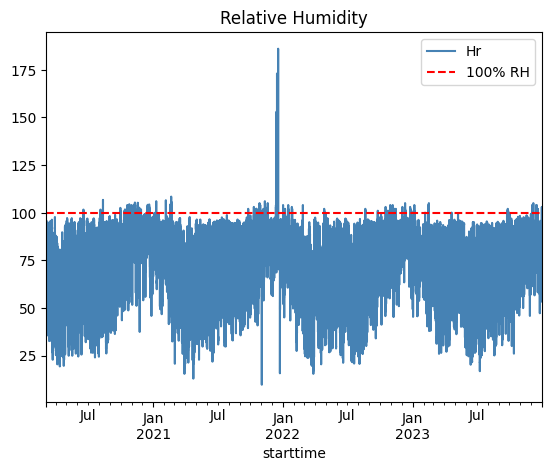

0.04% of Hr values are above 104%
0.56% of Hr values are above 100%


In [36]:
df_cleaned['Hr'].plot(title='Relative Humidity', color=main_color)
plt.axhline(100, color='red', linestyle='--', label='100% RH')
plt.legend()
plt.show()

percentage_above_104 = (df_cleaned['Hr'] > 104).mean() * 100
print(f"{percentage_above_104:.2f}% of Hr values are above 104%")

percentage_above_100 = (df_cleaned['Hr'] > 100).mean() * 100
print(f"{percentage_above_100:.2f}% of Hr values are above 100%")


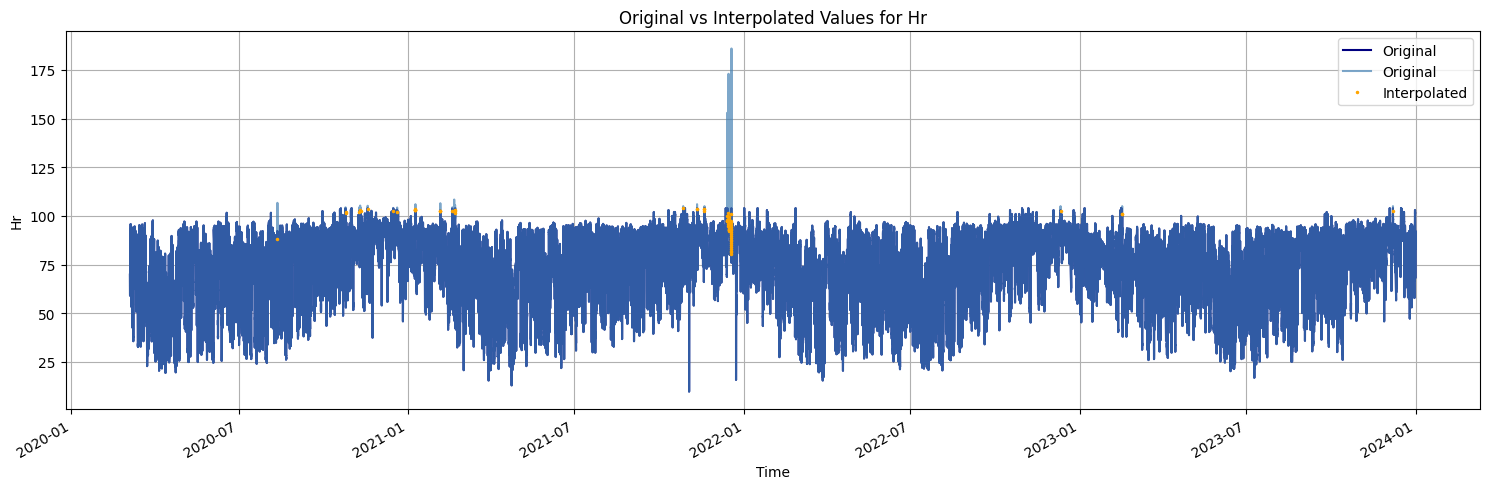

0.00% of Hr values are above 104%
0.54% of Hr values are above 100%


In [37]:
# Mask invalid values, those with value more than 104

# df_meteo.loc[invalid, 'Hr'] = np.nan

# Then interpolate short gaps, 1-day max
# df_meteo['Hr'] = df_meteo['Hr'].interpolate(method='linear', limit=144, limit_direction='both')
# find invalid values and mark them as missing
col = 'Hr'
original = df_cleaned[col].copy()
invalid = original > 104
original.loc[invalid] = np.nan

filled = original.interpolate(method='time', limit=144, limit_direction='both')

# Create mask where interpolation happened
interpolated_mask = original.isna() & filled.notna()

# Step 4: Plot
plt.figure(figsize=(15, 5))

# Original non-NaN values
filled[~interpolated_mask].plot(label='Original', color=dark_color)
df_cleaned[col].plot(label='Original', color=main_color, alpha=0.7)

# Interpolated values
filled[interpolated_mask].plot(label='Interpolated', linestyle='none', marker='.', markersize=3, color=accent_color)

plt.title(f'Original vs Interpolated Values for {col}')
plt.xlabel('Time')
plt.ylabel(col)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

df_cleaned[col] = filled

percentage_above_104 = (df_cleaned[col] > 104).mean() * 100
print(f"{percentage_above_104:.2f}% of Hr values are above 104%")

percentage_above_100 = (df_cleaned[col] > 100).mean() * 100
print(f"{percentage_above_100:.2f}% of Hr values are above 100%")

In [46]:
df_cleaned.to_parquet(path_df_cleaned)

In [38]:
df_cleaned.describe()

parameter,CO2,Hr,Hr_Trockner,NO,NO2,NOx,PM2.5,PN[5-100nm],RainDur,SO2,StrGlo,T,T_Trockner,WD,WVv,eBC2.5,year,hour,day_of_week,month,PM2.5_gap_too_long,PM2.5_was_interpolated,NOx_gap_too_long,NOx_was_interpolated,NO_gap_too_long,NO_was_interpolated,NO2_gap_too_long,NO2_was_interpolated,eBC2.5_gap_too_long,eBC2.5_was_interpolated,PN[5-100nm]_gap_too_long,PN[5-100nm]_was_interpolated,Hr_gap_too_long,Hr_was_interpolated,Hr_Trockner_gap_too_long,Hr_Trockner_was_interpolated,RainDur_gap_too_long,RainDur_was_interpolated,StrGlo_gap_too_long,StrGlo_was_interpolated,T_gap_too_long,T_was_interpolated,T_Trockner_gap_too_long,T_Trockner_was_interpolated,WD_gap_too_long,WD_was_interpolated,WVv_gap_too_long,WVv_was_interpolated
count,178618.000000,201168.000000,200638.000000,201168.000000,201168.000000,201168.000000,201168.000000,168749.000000,201168.000000,97154.000000,201168.000000,201168.000000,200638.000000,201168.000000,201168.000000,194653.000000,201168.000000,201168.000000,201168.000000,201168.000000,201168.0,201168.000000,201168.0,201168.000000,201168.0,201168.000000,201168.0,201168.000000,201168.000000,201168.000000,201168.000000,201168.000000,201168.0,201168.000000,201168.000000,201168.000000,201168.0,201168.000000,201168.0,201168.000000,201168.0,201168.000000,201168.000000,201168.000000,201168.0,201168.000000,201168.0,201168.000000
mean,444.005653,73.451606,25.810261,4.186420,16.056728,11.753023,8.648289,20695.748707,0.975887,0.391995,152.886453,11.551319,21.722602,169.484405,1.670588,0.318013,2021.567645,11.500000,3.004295,6.749463,0.0,0.000671,0.0,0.016041,0.0,0.016051,0.0,0.016056,0.032386,0.005662,0.161154,0.015360,0.0,0.005140,0.002635,0.014197,0.0,0.000875,0.0,0.000119,0.0,0.005026,0.002635,0.013710,0.0,0.002993,0.0,0.003007
std,32.908667,18.347617,9.229503,10.509917,12.112517,13.105350,5.974692,37140.489506,2.847437,0.605668,245.746347,8.037583,0.998428,108.365558,1.255319,0.287749,1.095597,6.922204,1.999642,3.354117,0.0,0.025897,0.0,0.125635,0.0,0.125673,0.0,0.125692,0.177023,0.075033,0.367674,0.122981,0.0,0.071509,0.051261,0.118303,0.0,0.029566,0.0,0.010922,0.0,0.070714,0.051261,0.116284,0.0,0.054622,0.0,0.054758
min,384.868065,9.700000,3.850000,-1.208949,-0.242115,-0.007394,1.257804,23.212007,0.000000,-0.201082,0.000000,-12.000000,17.000000,0.000000,0.000000,0.000000,2020.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
25%,420.458631,60.800000,17.900000,0.238448,7.069404,4.103600,4.738400,4247.524023,0.000000,0.115998,2.000000,5.300000,21.100000,72.000000,0.782000,0.140571,2021.000000,5.750000,1.000000,4.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
50%,434.977552,78.000000,25.200000,0.790454,12.307519,7.284250,7.312580,9078.877384,0.000000,0.238283,7.000000,11.300000,21.700000,133.000000,1.290000,0.229730,2022.000000,11.500000,3.000000,7.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
75%,462.083107,88.801923,32.700000,2.680827,21.900536,14.125548,11.058232,19940.840630,0.000000,0.453648,207.000000,17.400000,22.400000,274.000000,2.220000,0.402954,2023.000000,17.250000,5.000000,10.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
max,625.707082,104.000000,55.000000,211.722136,118.783754,211.932395,445.734000,694578.042012,10.000000,42.135267,1267.000000,36.800000,26.600000,360.000000,13.500000,16.289764,2023.000000,23.000000,6.000000,12.000000,0.0,1.000000,0.0,1

In [41]:
df_cleaned.index.min()

Timestamp('2020-03-05 00:00:00')

# Wind data (direction and speed)

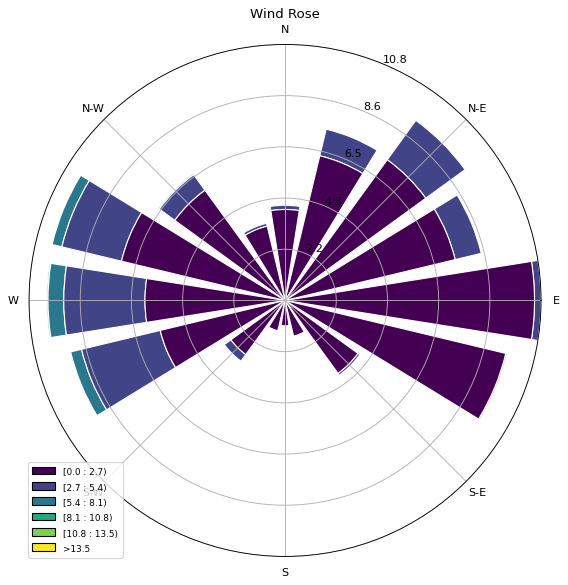

In [42]:
from windrose import WindroseAxes
import matplotlib.pyplot as plt

# Wind direction (degrees) and speed (if available)
wd = df_cleaned['WD'].dropna()
ws = df_cleaned['WVv'].reindex(wd.index)  # wind speed (optional)

# Plot wind rose
ax = WindroseAxes.from_ax()
ax.bar(wd, ws, normed=True, opening=0.8, edgecolor='white')
ax.set_legend()
plt.title('Wind Rose')
plt.show()


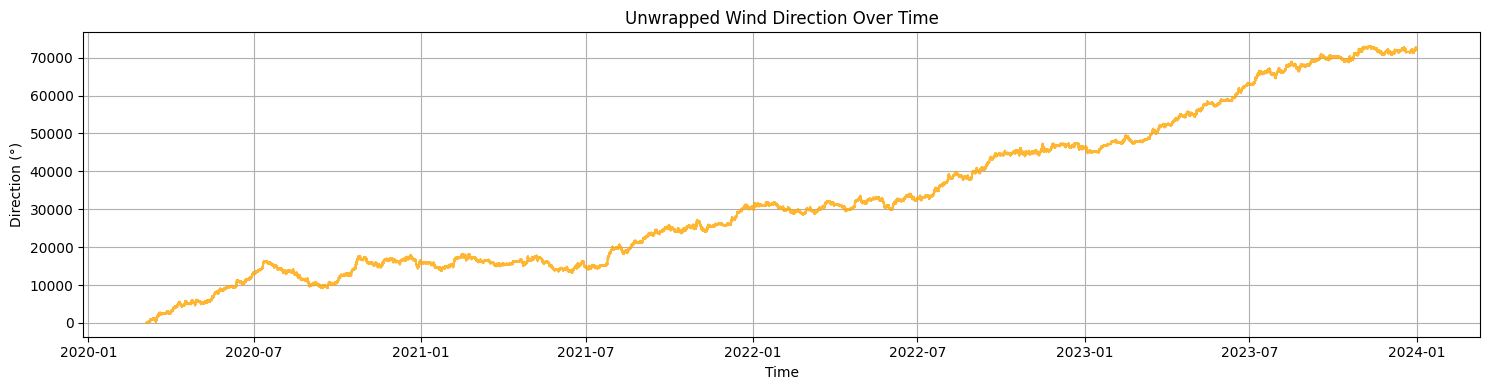

In [43]:
import numpy as np

wd_series = df_cleaned['WD'].dropna()

wd_rad = np.radians(wd_series)
wd_unwrapped = np.unwrap(wd_rad)
wd_unwrapped_deg = np.degrees(wd_unwrapped)

plt.figure(figsize=(15, 4))
plt.plot(wd_series.index, wd_unwrapped_deg, color='orange', alpha=0.8)
plt.title('Unwrapped Wind Direction Over Time')
plt.ylabel('Direction (°)')
plt.xlabel('Time')
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/pp/55r76hw53w51fgc71j966cfm0000gn/T/ipykernel_9973/1874364870.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



<Axes: title={'center': 'Avg PM2.5 by Wind Direction'}, xlabel='wind_sector'>

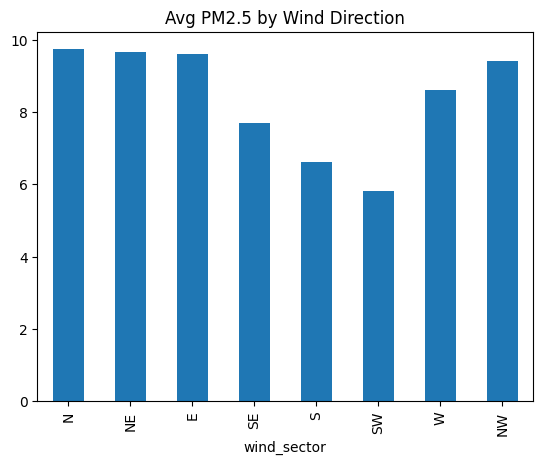

In [45]:
def wind_direction_sector(degrees):
    dirs = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
    bins = [0, 45, 90, 135, 180, 225, 270, 315, 360]
    return pd.cut(degrees % 360, bins=bins, labels=dirs, include_lowest=True, right=False)

df_cleaned['wind_sector'] = wind_direction_sector(df_meteo['WD'])

pollutant_means = df_cleaned.groupby('wind_sector')['PM2.5'].mean()
pollutant_means.plot(kind='bar', title='Avg PM2.5 by Wind Direction')


It seems like PM2.5 concentration is significantly smaller when wind direction is S/SW/SE

In [ ]:
def wind_direction_sector(degrees):
    dirs = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
    bins = [0, 45, 90, 135, 180, 225, 270, 315, 360]
    return pd.cut(degrees % 360, bins=bins, labels=dirs, include_lowest=True, right=False)

df_cleaned['wind_sector'] = wind_direction_sector(df_meteo['WD'])

pollutant_means = df_cleaned.groupby('wind_sector')['NOx'].mean()
pollutant_means.plot(kind='bar', title='Avg PM2.5 by Wind Direction')


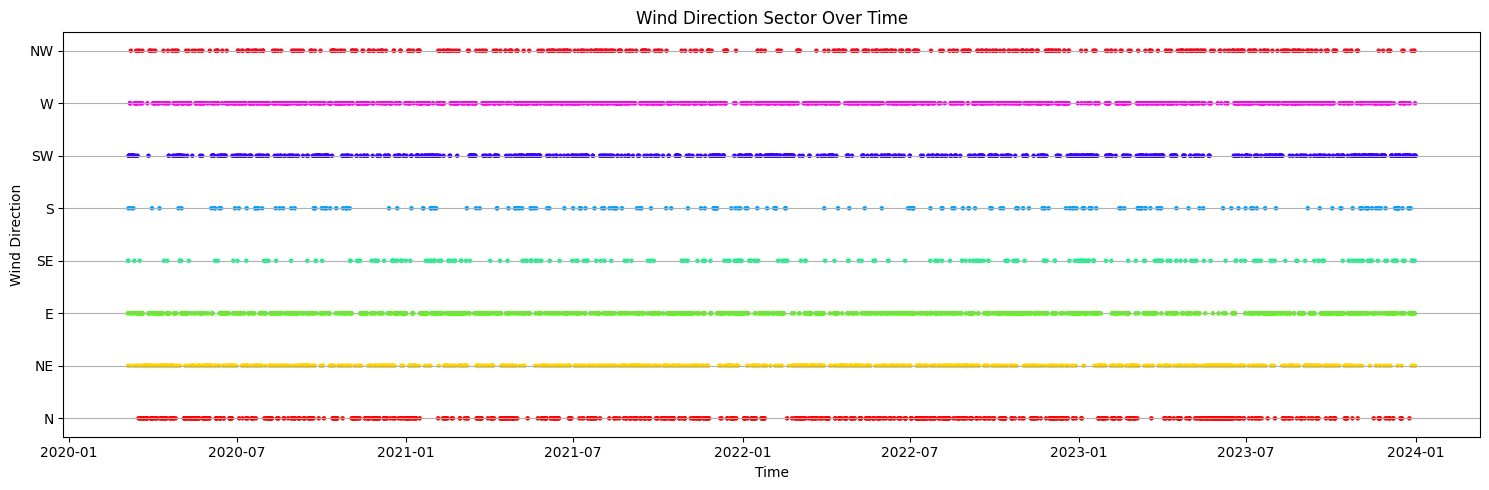

In [47]:


# Optional: sample to reduce clutter
df_sampled = df_cleaned[['wind_sector']].dropna().iloc[::30]  # Every 5 hours (30 × 10 min)

# Map compass directions to numbers (for y-axis)
sector_order = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
sector_map = {s: i for i, s in enumerate(sector_order)}
df_sampled['sector_num'] = df_sampled['wind_sector'].map(sector_map)

plt.figure(figsize=(15, 5))
plt.scatter(df_sampled.index, df_sampled['sector_num'], c=df_sampled['sector_num'], cmap='hsv', s=5)
plt.yticks(range(len(sector_order)), sector_order)
plt.title('Wind Direction Sector Over Time')
plt.xlabel('Time')
plt.ylabel('Wind Direction')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


/var/folders/pp/55r76hw53w51fgc71j966cfm0000gn/T/ipykernel_9973/1463038501.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



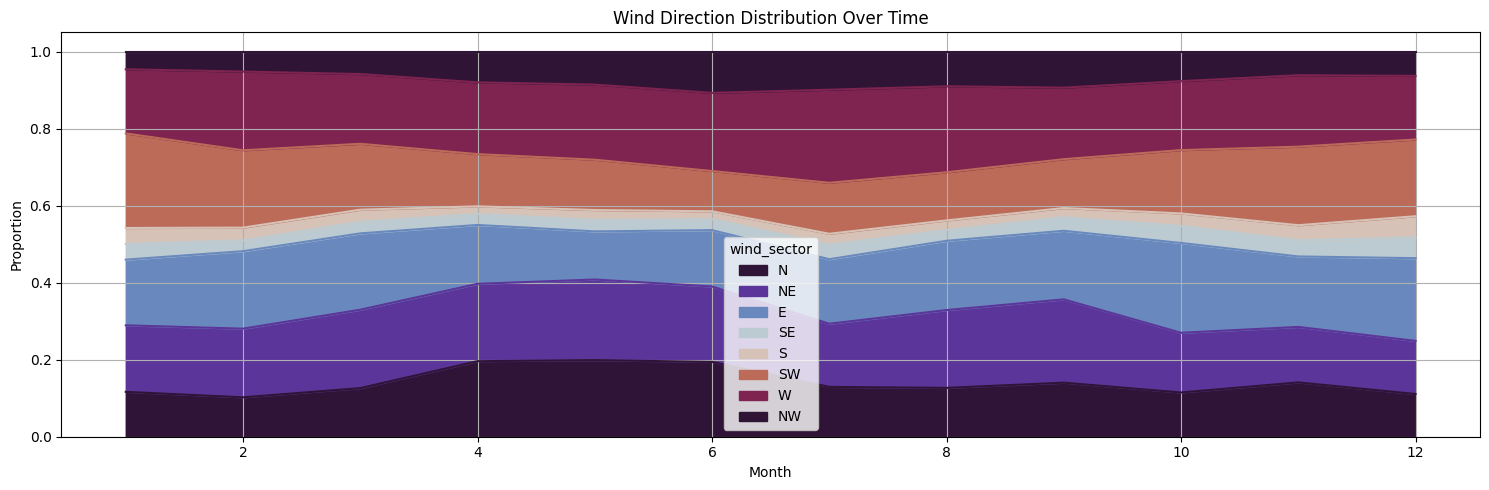

In [48]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# # Get evenly spaced colors from HSV (wraps around hue wheel)
# cmap = cm.get_cmap('hsv', 8)
# colors = [mcolors.to_hex(cmap(i)) for i in range(8)]


# Group by month and direction
direction_counts = df_cleaned.groupby(['month', 'wind_sector']).size().unstack(fill_value=0)

# Normalize to percent
direction_freq = direction_counts.div(direction_counts.sum(axis=1), axis=0)

# Plot as stacked area chart
direction_freq.plot(kind='area', figsize=(15, 5), colormap='twilight_shifted')
plt.title('Wind Direction Distribution Over Time')
plt.ylabel('Proportion')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()
